# Data Preprocessing

## Import Library

In [ ]:
import os
import random
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# ============================================================
# SET GLOBAL RANDOM SEED UNTUK REPRODUCIBILITY
# ============================================================
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Load Data

In [ ]:
file_path = '/content/AQI_Jakarta_2024_with_spatial_embedding.csv'
AQI_Jakarta_df = pd.read_csv(file_path, encoding='latin1')
AQI_Jakarta_df.head()

,Station_Name,Station_ID,Latitude,Longitude,Date,Waktu,PM10,PM2.5,SO2,CO,...,Congestion Level,Temperature,Dew Point,Humidity,Wind,Wind Speed,Pressure,Condition,x_km,y_km
0,Bundaran_HI,1.0,-6.195,106.82159,1/1/2024,0:00,-,-,-,-,...,103.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.809789,5.149839
1,Bundaran_HI,1.0,-6.195,106.82159,1/1/2024,1:00,-,-,-,-,...,111.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.809789,5.149839
2,Bundaran_HI,1.0,-6.195,106.82159,1/1/2024,2:00,-,-,-,-,...,27.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.809789,5.149839
3,Bundaran_HI,1.0,-6.195,106.82159,1/1/2024,3:00,56,86,54,7,...,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.809789,5.149839
4,Bundaran_HI,1.0,-6.195,106.82159,1/1/2024,4:00,57,88,54,8,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.809789,5.149839


## Menampilkan Nama Kolom Dataset

In [ ]:
AQI_Jakarta_df.columns

Index(['Station_Name', 'Station_ID', 'Latitude', 'Longitude', 'Date', 'Waktu',
       'PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2', 'Speed', 'Congestion Level',
       'Temperature', 'Dew Point', 'Humidity', 'Wind', 'Wind Speed',
       'Pressure', 'Condition', 'x_km', 'y_km'],
      dtype='object')

## Menaampilkan Informasi Tipe Kolom Dataset

In [ ]:
AQI_Jakarta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43922 entries, 0 to 43921
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Station_Name      43921 non-null  object 
 1   Station_ID        43921 non-null  float64
 2   Latitude          43921 non-null  float64
 3   Longitude         43921 non-null  float64
 4   Date              43921 non-null  object 
 5   Waktu             43921 non-null  object 
 6   PM10              43921 non-null  object 
 7   PM2.5             43921 non-null  object 
 8   SO2               43921 non-null  object 
 9   CO                43921 non-null  object 
 10  O3                43921 non-null  object 
 11  NO2               43921 non-null  object 
 12  Speed             17040 non-null  float64
 13  Congestion Level  17040 non-null  float64
 14  Temperature       35937 non-null  object 
 15  Dew Point         35937 non-null  object 
 16  Humidity          35937 non-null  object

## Menampilkan Statistik Dataset

In [ ]:
AQI_Jakarta_df.describe()

,Station_ID,Latitude,Longitude,Speed,Congestion Level,Wind Speed,x_km,y_km
count,43921.000000,43921.000000,43921.000000,17040.000000,17040.000000,35937.000000,4.392100e+04,4.392100e+04
mean,2.999954,-6.241395,106.837992,33.583327,32.810252,6.145226,-9.769821e-11,9.805107e-10
std,1.414246,0.070617,0.059893,13.690590,31.490430,4.270416,6.608748e+00,7.838447e+00
min,1.000000,-6.355240,106.751930,8.800000,0.000000,0.000000,-9.496218e+00,-1.263680e+01
25%,2.000000,-6.288420,106.805020,21.500000,3.800000,3.000000,-3.638157e+00,-5.219781e+00
50%,3.000000,-6.207150,106.821590,30.800000,27.500000,6.000000,-1.809789e+00,3.801189e+00
75%,4.000000,-6.195000,106.904790,45.800000,53.100000,9.000000,7.370671e+00,5.149839e+00
max,5.000000,-6.161170,106.906630,70.500000,255.900000,29.000000,7.573700e+00,8.904969e+00


## Melakukan Pengecekan Jumlah Missing Values dan Null Data

In [ ]:
print('--- DataFrame Info ---')
AQI_Jakarta_df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43922 entries, 0 to 43921
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Station_Name      43921 non-null  object 
 1   Station_ID        43921 non-null  float64
 2   Latitude          43921 non-null  float64
 3   Longitude         43921 non-null  float64
 4   Date              43921 non-null  object 
 5   Waktu             43921 non-null  object 
 6   PM10              43921 non-null  object 
 7   PM2.5             43921 non-null  object 
 8   SO2               43921 non-null  object 
 9   CO                43921 non-null  object 
 10  O3                43921 non-null  object 
 11  NO2               43921 non-null  object 
 12  Speed             17040 non-null  float64
 13  Congestion Level  17040 non-null  float64
 14  Temperature       35937 non-null  object 
 15  Dew Point         35937 non-null  object 
 16  Humidity         

## Menghapus baris yang bernilai null

In [ ]:
## Menghapus baris yang NA dan NULL

AQI_Jakarta_df.dropna(inplace=True)
mask_to_drop = AQI_Jakarta_df.isin(['-', '0']).any(axis=1)
AQI_Jakarta_df.drop(AQI_Jakarta_df.loc[mask_to_drop].index, inplace=True)
AQI_Jakarta_df.isnull().sum()

,0
Station_Name,0
Station_ID,0
Latitude,0
Longitude,0
Date,0
Waktu,0
PM10,0
PM2.5,0
SO2,0
CO,0


In [ ]:
print('\n--- Missing Values Count ---')
print(AQI_Jakarta_df.isnull().sum())


--- Missing Values Count ---
Station_Name        0
Station_ID          0
Latitude            0
Longitude           0
Date                0
Waktu               0
PM10                0
PM2.5               0
SO2                 0
CO                  0
O3                  0
NO2                 0
Speed               0
Congestion Level    0
Temperature         0
Dew Point           0
Humidity            0
Wind                0
Wind Speed          0
Pressure            0
Condition           0
x_km                0
y_km                0
dtype: int64


## Data Transformation

In [ ]:
AQI_Jakarta_df["datetime"] = pd.to_datetime(
    AQI_Jakarta_df["Date"].astype(str) + " " + AQI_Jakarta_df["Waktu"].astype(str),
    errors="coerce"
)

AQI_Jakarta_df = AQI_Jakarta_df.dropna(subset=["datetime", "Station_ID"]).copy()
pollutant_cols_local = ["PM10", "PM2.5", "SO2", "CO", "O3", "NO2"]
numeric_features_to_convert = [
    "Temperature",
    "Dew Point",
    "Humidity",
    "Wind Speed",
    "Pressure",
    "Speed", # Added Speed to ensure numeric conversion
    "Congestion Level", # Added Congestion Level to ensure numeric conversion
    "x_km",
    "y_km"
]
cols_to_convert_to_numeric = [c for c in (pollutant_cols_local + numeric_features_to_convert) if c in AQI_Jakarta_df.columns]
for col in cols_to_convert_to_numeric:
    AQI_Jakarta_df[col] = pd.to_numeric(AQI_Jakarta_df[col].replace("-", np.nan), errors="coerce")
# Combine all columns that need to be ensured as numeric, excluding those that will be one-hot encoded
cols_to_convert_to_numeric = [c for c in (pollutant_cols_local + numeric_features_to_convert) if c in AQI_Jakarta_df.columns]

for col in cols_to_convert_to_numeric:
    AQI_Jakarta_df[col] = pd.to_numeric(AQI_Jakarta_df[col].replace("-", np.nan), errors="coerce")

In [ ]:
# Convert the 'Date' column itself to datetime objects
AQI_Jakarta_df['Date'] = pd.to_datetime(AQI_Jakarta_df['Date'], errors='coerce')

## Create Temporal Features

In [ ]:
AQI_Jakarta_df["hour"] = AQI_Jakarta_df["datetime"].dt.hour
AQI_Jakarta_df["dayofweek"] = AQI_Jakarta_df["datetime"].dt.dayofweek

## Create Lag Time Features for Pollutant, Traffic and Meterology Features

In [ ]:

# Clean column names to remove any invisible characters like BOM (Byte Order Mark)
AQI_Jakarta_df.columns = AQI_Jakarta_df.columns.str.strip().str.replace('ï»¿', '')

# --- Code prepended for Data Transformation (original location: LmK28_qljXB9) ---
AQI_Jakarta_df["datetime"] = pd.to_datetime(
    AQI_Jakarta_df["Date"].astype(str) + " " + AQI_Jakarta_df["Waktu"].astype(str),
    errors="coerce"
)

# --- Temporal Features (from VHhGnLD8j3m0 current content) ---
AQI_Jakarta_df["hour"] = AQI_Jakarta_df["datetime"].dt.hour
AQI_Jakarta_df["dayofweek"] = AQI_Jakarta_df["datetime"].dt.dayofweek

# Sort by Station_ID and datetime to ensure correct lag calculation
AQI_Jakarta_df = AQI_Jakarta_df.sort_values(by=['Station_ID', 'datetime']).reset_index(drop=True)

# --- Define features to create lag for (Pollutants, Meteorology, Traffic) ---
features_to_lag = [
    *pollutant_cols_local,
    "Temperature", "Dew Point", "Humidity", "Wind Speed", "Pressure", # Meteorology
    "Speed", "Congestion Level" # Traffic
]

lag_hours = [1] # Lag 1 Hour

new_lag_cols_to_add = []
for feature in features_to_lag:
    for lag in lag_hours:
        new_col_name = f'{feature}_lag_{lag}'
        # Apply lag grouped by Station_ID
        AQI_Jakarta_df[new_col_name] = AQI_Jakarta_df.groupby('Station_ID')[feature].shift(lag)
        new_lag_cols_to_add.append(new_col_name)

# --- Update critical_cols_for_dropna ---
# Include all original features used for lag creation, plus the newly generated lagged features
critical_cols_for_dropna = pollutant_cols_local + numeric_features_to_convert + new_lag_cols_to_add + ["datetime", "Station_ID", "hour", "dayofweek"]
critical_cols_present = [col for col in critical_cols_for_dropna if col in AQI_Jakarta_df.columns]
AQI_Jakarta_df.dropna(subset=critical_cols_present, inplace=True)

# Display the head of the DataFrame with new global lag features for verification
display_cols = [
    'PM2.5', 'PM2.5_lag_1', 'Temperature', 'Temperature_lag_1',
    'Speed', 'Speed_lag_1', 'Congestion Level', 'Congestion_Level_lag_1',
    'Dew Point', 'Humidity', 'Wind Speed', 'Pressure'
]
display(AQI_Jakarta_df[[col for col in display_cols if col in AQI_Jakarta_df.columns]].head())

,PM2.5,PM2.5_lag_1,Temperature,Temperature_lag_1,Speed,Speed_lag_1,Congestion Level,Dew Point,Humidity,Wind Speed,Pressure
1,90,89.0,77,77.0,33.0,36.5,0.0,75,94,3.0,29.70
2,89,90.0,86,77.0,29.8,33.0,8.6,77,74,3.0,29.76
3,88,89.0,90,86.0,27.2,29.8,20.7,77,66,7.0,29.76
4,88,88.0,91,90.0,24.8,27.2,34.3,77,63,3.0,29.70
5,89,88.0,90,91.0,24.2,24.8,36.4,77,66,6.0,29.65


## Visualisasi Data
Untuk mengetahui sebaran data serta identifikasi outliers dilakukan visualisasi data dengan plotting setiap fitur dalam bentuk grafik

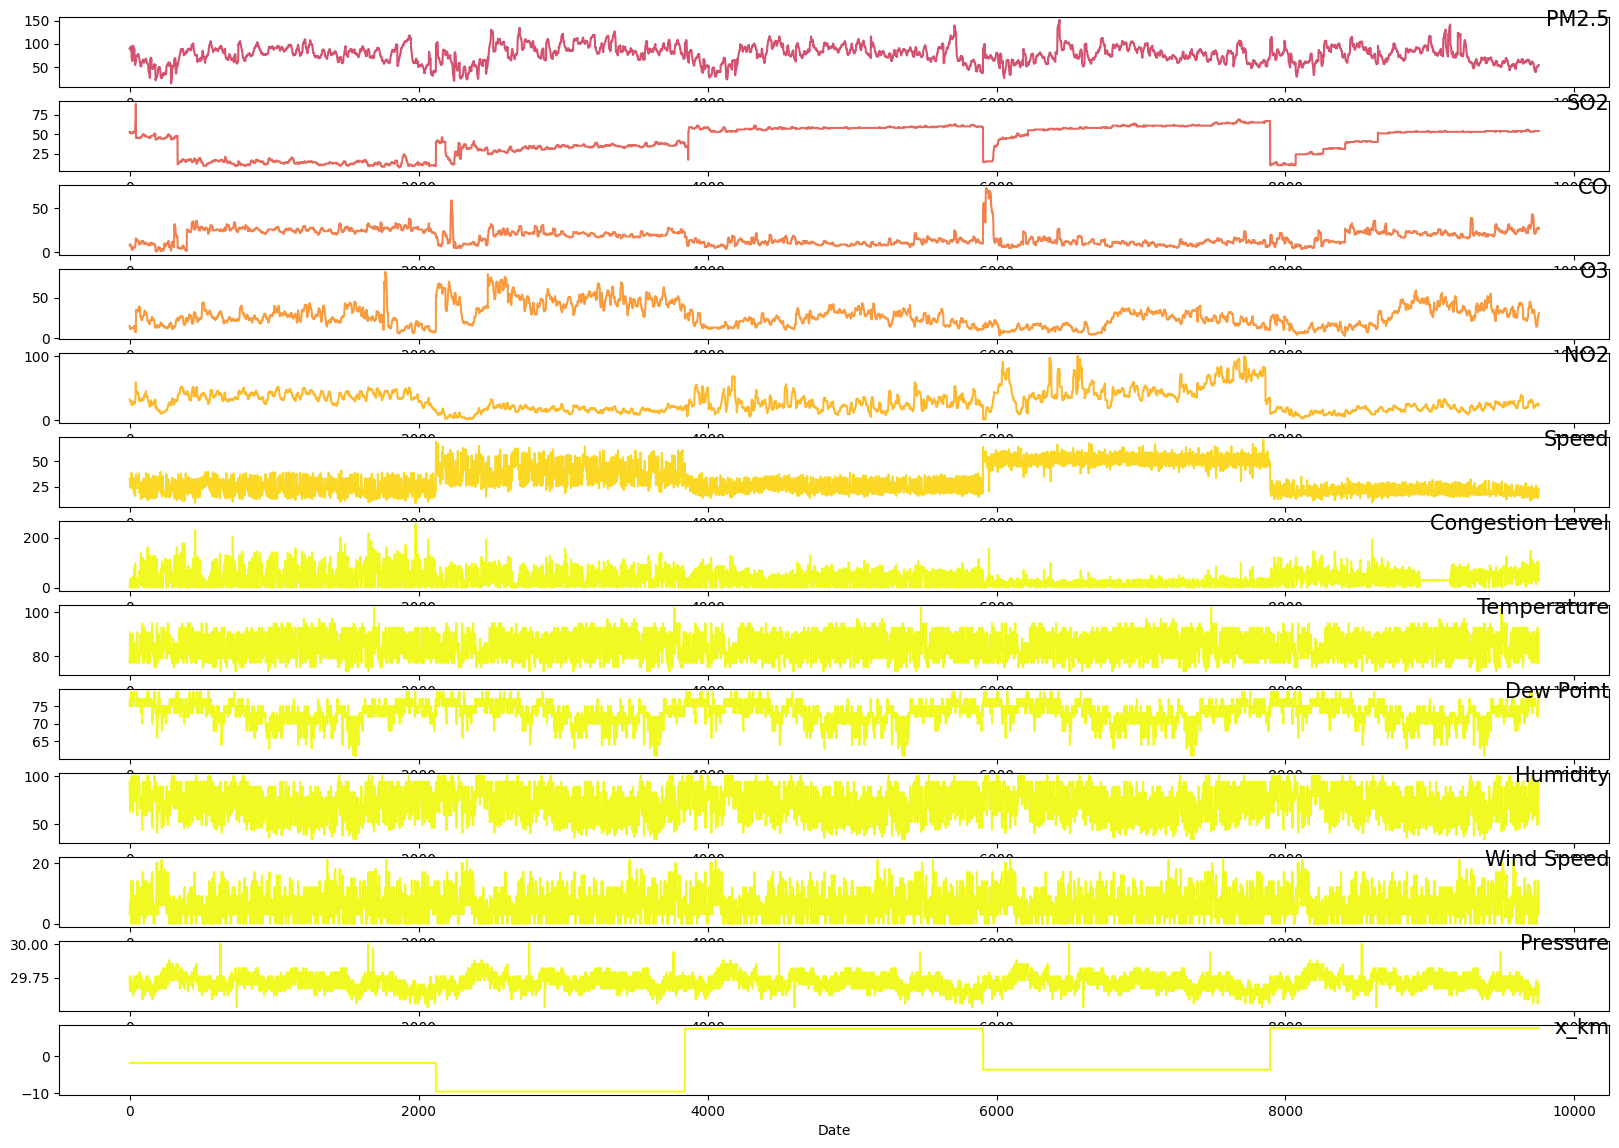

In [ ]:
import matplotlib.cm as cm

values = AQI_Jakarta_df.values

# specify columns to plot, excluding 'Wind' (index 17) and 'Condition' (index 20)
groups = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 21]
i = 1

# plot each column
plt.figure(figsize=(20,14))
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group], color=cm.plasma(group/len(groups)))
    plt.xlabel('Date')
    plt.title(AQI_Jakarta_df.columns[group], y=0.75, loc='right', fontsize = 15)
    i += 1
plt.show()

## Data Scaling & Normalization

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Columns to normalize
numerical_cols = ['PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2', 'Speed', 'Congestion Level', 'Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Pressure']

# Create a copy of the DataFrame to store normalized values
AQI_Jakarta_normalized_df = AQI_Jakarta_df.copy()

# Apply normalization to the selected columns
AQI_Jakarta_normalized_df[numerical_cols] = scaler.fit_transform(AQI_Jakarta_df[numerical_cols])

# Display the head of the normalized DataFrame
display(AQI_Jakarta_normalized_df.head())

,Station_Name,Station_ID,Latitude,Longitude,Date,Waktu,PM10,PM2.5,SO2,CO,...,CO_lag_1,O3_lag_1,NO2_lag_1,Temperature_lag_1,Dew Point_lag_1,Humidity_lag_1,Wind Speed_lag_1,Pressure_lag_1,Speed_lag_1,Congestion Level_lag_1
1,Bundaran_HI,1.0,-6.195,106.82159,2024-01-01,6:00,0.264865,0.550725,0.560976,0.097222,...,8.0,15.0,32.0,77.0,75.0,94.0,3.0,29.70,36.5,0.0
2,Bundaran_HI,1.0,-6.195,106.82159,2024-01-01,9:00,0.281081,0.543478,0.560976,0.111111,...,8.0,15.0,32.0,77.0,75.0,94.0,3.0,29.70,33.0,0.0
3,Bundaran_HI,1.0,-6.195,106.82159,2024-01-01,11:00,0.286486,0.536232,0.560976,0.111111,...,9.0,13.0,31.0,86.0,77.0,74.0,3.0,29.76,29.8,8.6
4,Bundaran_HI,1.0,-6.195,106.82159,2024-01-01,12:00,0.286486,0.536232,0.548780,0.111111,...,9.0,12.0,30.0,90.0,77.0,66.0,7.0,29.76,27.2,20.7
5,Bundaran_HI,1.0,-6.195,106.82159,2024-01-01,15:00,0.291892,0.543478,0.548780,0.111111,...,9.0,11.0,30.0,91.0,77.0,63.0,3.0,29.70,24.8,34.3


## Penelaahan Korelasi Antar Fitur

### Pearson Correlation

In [ ]:
AQI_Jakarta_df.select_dtypes(include=np.number).corr()

,Station_ID,Latitude,Longitude,PM10,PM2.5,SO2,CO,O3,NO2,Speed,...,CO_lag_1,O3_lag_1,NO2_lag_1,Temperature_lag_1,Dew Point_lag_1,Humidity_lag_1,Wind Speed_lag_1,Pressure_lag_1,Speed_lag_1,Congestion Level_lag_1
Station_ID,1.000000,-0.664721,0.503816,0.253377,-0.050865,0.584657,-0.237146,-0.190361,-0.044262,0.131130,...,-0.236471,-0.190571,-0.044637,0.008258,0.001639,-0.005279,0.008728,0.009265,0.131026,-0.206036
Latitude,-0.664721,1.000000,0.142451,-0.071723,0.069299,-0.291436,0.086751,0.193615,-0.339022,-0.567339,...,0.085857,0.193800,-0.338556,-0.009254,0.004703,0.009376,-0.004563,-0.000523,-0.567119,0.286217
Longitude,0.503816,0.142451,1.000000,0.356076,-0.088032,0.329295,-0.153666,-0.363550,-0.134848,-0.580000,...,-0.153761,-0.363707,-0.134806,-0.000519,0.018719,0.008592,-0.000299,-0.018834,-0.579931,0.079598
PM10,0.253377,-0.071723,0.356076,1.000000,0.686740,0.093037,0.175889,0.098216,0.056301,-0.182218,...,0.177275,0.096769,0.057710,0.079531,-0.125597,-0.119095,-0.079358,0.021790,-0.181018,-0.031040
PM2.5,-0.050865,0.069299,-0.088032,0.686740,1.000000,-0.027973,0.220135,0.357696,0.027920,0.052488,...,0.217328,0.354601,0.025790,0.116809,-0.191223,-0.178701,-0.087678,0.009430,0.053874,-0.057417
SO2,0.584657,-0.291436,0.329295,0.093037,-0.027973,1.000000,-0.550256,-0.120616,0.188957,0.294247,...,-0.550992,-0.121079,0.188719,0.033474,-0.074479,-0.058149,0.026628,-0.041491,0.293907,-0.299671
CO,-0.237146,0.086751,-0.153666,0.175889,0.220135,-0.550256,1.000000,0.223994,-0.014331,-0.217583,...,0.992408,0.223308,-0.018709,-0.025325,0.025542,0.031917,-0.088552,-0.036770,-0.217427,0.202890
O3,-0.190361,0.193615,-0.363550,0.098216,0.357696,-0.120616,0.223994,1.000000,-0.281822,0.025963,...,0.224751,0.994415,-0.279726,0.059933,-0.196030,-0.132092,-0.051356,0.011118,0.025872,0.058223
NO2,-0.044262,-0.339022,-0.134848,0.056301,0.027920,0.188957,-0.014331,-0.281822,1.000000,0.350616,...,-0.016198,-0.282384,0.992781,-0.013778,0.039519,0.028260,-0.045836,-0.093994,0.349642,-0.162427
Speed,0.131130,-0.567339,-0.580000,-0.182218,0.052488,0.294247,-0.217583,0.025963,0.350616,1.000000,...,-0.217625,0.026868,0.349977,-0.136079,0.018235,0.110650,-0.125850,0.092895,0.949913,-0.617422


### Menampilkan Pearson Correlation dalam bentuk grafik heatmap

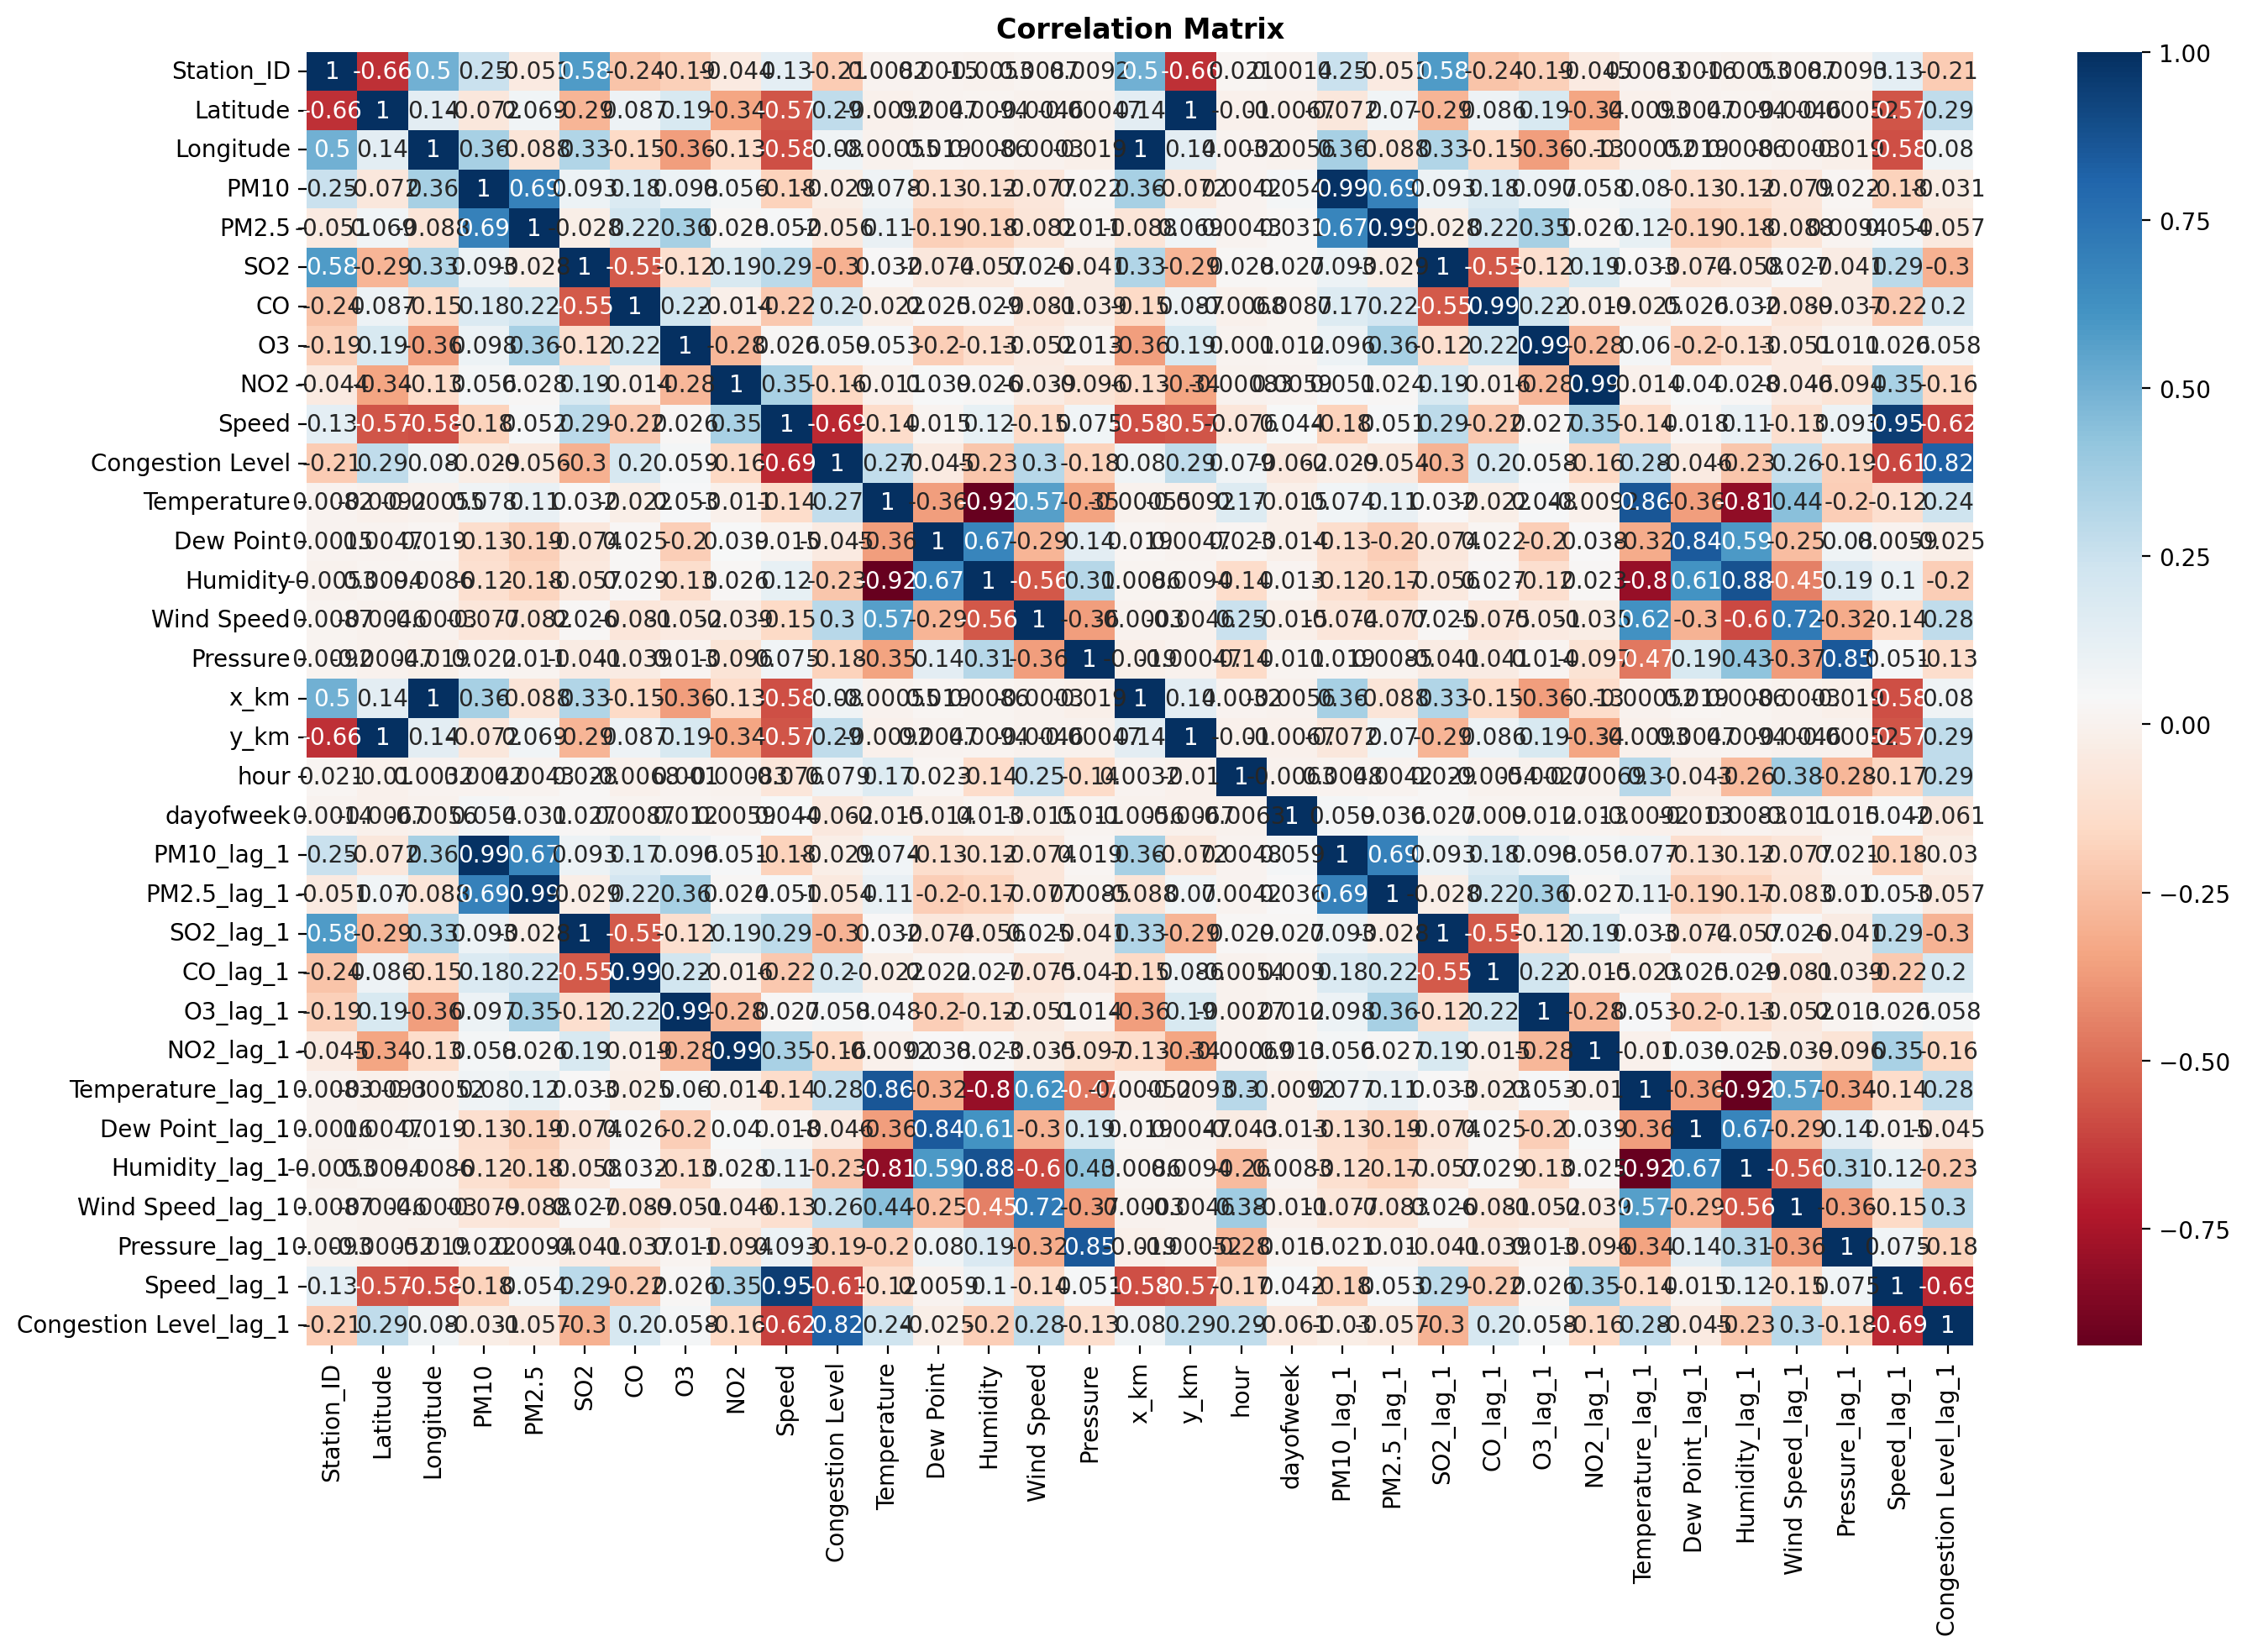

In [ ]:
import seaborn as sns

plt.figure(figsize = (16,10), dpi=200)
ax = plt.axes()
sns.heatmap(AQI_Jakarta_df.select_dtypes(include=np.number).corr(), annot = True, cmap='RdBu', ax=ax)
ax.set_title('Correlation Matrix', weight='bold')
plt.show()

# Model Development

## Data Splitting
Pada proses data splitting, data dibagi menjadi train set sebanyak 75%, validation set sebanyak 15% dari traning set dan test set sebanyak 25%.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Clean column names to remove any invisible characters like BOM (Byte Order Mark)
AQI_Jakarta_df.columns = AQI_Jakarta_df.columns.str.strip().str.replace('ï»¿', '')

# Define target variables
target_cols = ['PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2']

# 1. Create Y (target variables)
Y = AQI_Jakarta_df[target_cols].copy()
for col in Y.columns:
    if Y[col].dtype == 'object':
        Y[col] = pd.to_numeric(Y[col], errors='coerce')
Y = Y.select_dtypes(include=np.number)

# 2. Create X (features) by explicit selection
# Base numeric features (current values of meteorology, spatial, and temporal features)
base_numeric_features = [
    'Temperature',
    'Dew Point',
    'Humidity',
    'Wind Speed',
    'Pressure',
    'x_km',
    'y_km',
    'hour',
    'dayofweek' # Add dayofweek as a base feature
]

# Dynamically collect all newly created lagged features
# These lists should match the definitions in the previous cell (ABehTZzOBM8U)
pollutant_cols_local = ["PM10", "PM2.5", "SO2", "CO", "O3", "NO2"]
meteorological_cols = ["Temperature", "Dew Point", "Humidity", "Wind Speed", "Pressure"]
traffic_cols = ["Speed", "Congestion Level"]
features_to_lag_for_X = pollutant_cols_local + meteorological_cols + traffic_cols
lag_hours = [1] # Ensure this matches the previous cell

lagged_features = []
for feature in features_to_lag_for_X:
    for lag in lag_hours:
        lagged_features.append(f'{feature}_lag_{lag}')

# Combine all desired X features
final_x_features = base_numeric_features + lagged_features

# Filter to ensure only existing columns are included (robustness)
final_x_features_present = [col for col in final_x_features if col in AQI_Jakarta_df.columns]
X = AQI_Jakarta_df[final_x_features_present].copy()

# Ensure all remaining columns in X are numeric, convert objects to numeric where possible
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.select_dtypes(include=np.number)

# --- NEW ROBUST NaN HANDLING: Align X and Y by dropping NaNs from a combined DataFrame ---
# Ensure X and Y are aligned on their indices
common_index = X.index.intersection(Y.index)
X = X.loc[common_index]
Y = Y.loc[common_index]

# Concatenate X and Y for combined NaN handling
combined_df = pd.concat([X, Y], axis=1)
combined_df.dropna(inplace=True) # Drop rows where any feature or target is NaN

# Re-split X and Y from the cleaned combined DataFrame
X = combined_df[X.columns]
Y = combined_df[Y.columns]
# --- END NEW ROBUST NaN HANDLING ---


# Split data into training set (75%), validation set (15% of 75%), and test set (25%)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, shuffle=False, random_state=42)
X_train, X_val_data, y_train, Y_val_data = train_test_split(X_train, y_train, test_size=0.15, shuffle=False, random_state=42)

# Menampilkan dimensi dataset, training set, validation set dan test set
print("AQI Data shape (original):", AQI_Jakarta_df.shape)
print("Features (X) shape (after cleaning):", X.shape)
print("Targets (Y) shape (after cleaning):", Y.shape)
print("Total number of features in X:", X.shape[1])
print("Features in X:", X.columns.tolist()) # Display ALL features
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val_data))
print("Test set size:", len(X_test))

AQI Data shape (original): (9754, 39)
Features (X) shape (after cleaning): (9754, 22)
Targets (Y) shape (after cleaning): (9754, 6)
Total number of features in X: 22
Features in X: ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Pressure', 'x_km', 'y_km', 'hour', 'dayofweek', 'PM10_lag_1', 'PM2.5_lag_1', 'SO2_lag_1', 'CO_lag_1', 'O3_lag_1', 'NO2_lag_1', 'Temperature_lag_1', 'Dew Point_lag_1', 'Humidity_lag_1', 'Wind Speed_lag_1', 'Pressure_lag_1', 'Speed_lag_1', 'Congestion Level_lag_1']
Training set size: 6217
Validation set size: 1098
Test set size: 2439


### Data Reshaping
Input data berupa 3D, yaitu (batch_size, timesteps, features) sehingga perlu reshaping data

In [ ]:
X_train = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_data = X_val_data.values.reshape((X_val_data.shape[0], 1, X_val_data.shape[1]))
X_test = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train = y_train.values
y_val_data = Y_val_data.values
y_test = y_test.values

## Build Transformer Model


Epoch 1: val_loss improved from None to 1261.10742, saving model to best_model_Transformer.weights.h5

Epoch 1: finished saving model to best_model_Transformer.weights.h5

Epoch 2: val_loss improved from 1261.10742 to 226.60335, saving model to best_model_Transformer.weights.h5

Epoch 2: finished saving model to best_model_Transformer.weights.h5

Epoch 3: val_loss improved from 226.60335 to 191.57634, saving model to best_model_Transformer.weights.h5

Epoch 3: finished saving model to best_model_Transformer.weights.h5

Epoch 4: val_loss did not improve from 191.57634

Epoch 5: val_loss did not improve from 191.57634

Epoch 6: val_loss did not improve from 191.57634

Epoch 7: val_loss improved from 191.57634 to 177.68614, saving model to best_model_Transformer.weights.h5

Epoch 7: finished saving model to best_model_Transformer.weights.h5

Epoch 8: val_loss improved from 177.68614 to 153.89978, saving model to best_model_Transformer.weights.h5

Epoch 8: finished saving model to best_mo

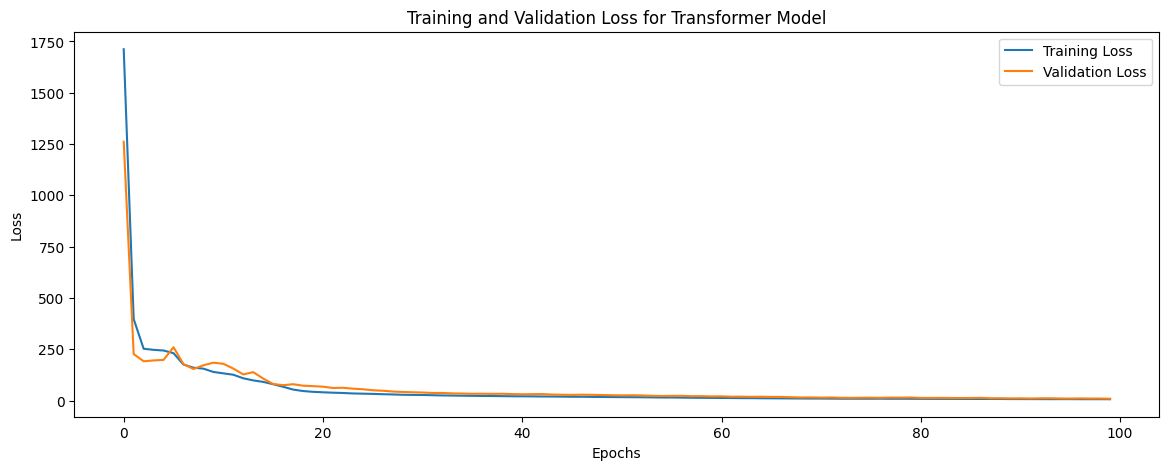

In [ ]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense
from tensorflow.keras.metrics import RootMeanSquaredError

tf.keras.backend.clear_session()
import tensorflow as tf

# Reset seed setelah clear_session
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Define the Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu", kernel_regularizer=l2(1e-4)), Dense(embed_dim, kernel_regularizer=l2(1e-4)), ]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None): # Modified: make training optional
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # Here, inputs (74 features) + attn_output (embed_dim) must match
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Model Parameters
embed_dim = X_train.shape[2]
num_heads = 2  # Number of attention heads
ff_dim = 16  # Hidden layer size in feed forward network inside transformer

# Build the Transformer Model
model_Transformer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(24, X_train.shape[2])),  # Modified: Input layer shape to (24, features)
    TransformerBlock(embed_dim, num_heads, ff_dim), # Transformer Block now receives (None, 24, embed_dim)
    tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4))
])

model_Transformer.compile(optimizer='adamw', loss='mse', metrics=[RootMeanSquaredError()])
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
checkpoint = ModelCheckpoint('best_model_Transformer.weights.h5', monitor='val_loss', save_best_only=True, verbose=1, save_weights_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

# Ensure X_train and X_val_data are of float type for model input
X_train_for_fit = X_train.astype(float)
X_val_data_for_fit = X_val_data.astype(float)

model_history_Transformer  = model_Transformer.fit(
    X_train_for_fit, y_train,
    epochs=100, verbose=0,
    validation_data=(X_val_data_for_fit, Y_val_data),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    shuffle=False
)

#Plot model ke grafik
plt.figure(figsize=(14,5))
plt.plot(model_history_Transformer.history['loss'], label='Training Loss')
plt.plot(model_history_Transformer.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for Transformer Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Proses Training dan Evaluasi
Pada proses ini seluruh model diuji pada training set dan dibandingkan hasilnya menggunakan metric MAE, R2, RMSE dan sMAPE

In [ ]:
def smape(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    # Handle cases where denominator is zero to avoid division by zero errors.
    # If both y_true and y_pred are 0, sMAPE for that point is 0.
    # Otherwise, perform division.
    return np.mean(numerator / np.where(denominator == 0, 1, denominator)) * 100

## Model Training

In [ ]:
custom_objects = {
    'mse': tf.keras.losses.MeanSquaredError(),  # Provide an instance of the loss function
    'RootMeanSquaredError': tf.keras.metrics.RootMeanSquaredError,
    'TransformerBlock': TransformerBlock # Add TransformerBlock to custom_objects
}

embed_dim = X_train.shape[2]
num_heads = 2
ff_dim = 16

# Rebuild the Transformer Model architecture
best_model_Transformer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(24, X_train.shape[2])),  # Modified: Input layer shape to (24, features)
    TransformerBlock(embed_dim, num_heads, ff_dim), # Transformer Block
    tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4))
])

best_model_Transformer.compile(optimizer='adamw', loss='mse', metrics=[RootMeanSquaredError()])
best_model_Transformer.load_weights('best_model_Transformer.weights.h5')

# X_train is already reshaped to (samples, timesteps, features) and converted to float in G_c8s3IIYp_H
X_train_for_evaluation = X_train.astype(float)

# Evaluate the model on the training set to get RMSE
_, rmse_train = best_model_Transformer.evaluate(X_train_for_evaluation, y_train, verbose=0)

# Make predictions on the training set
train_predictions = best_model_Transformer.predict(X_train_for_evaluation)

# Flatten y_train and predictions for metric calculations
y_train_flat = y_train.flatten()
train_predictions_flat = train_predictions.flatten()

# Calculate MAE, R2, and sMAPE
mae_train = mean_absolute_error(y_train_flat, train_predictions_flat)
r2_train = r2_score(y_train_flat, train_predictions_flat)
smape_train = smape(y_train_flat, train_predictions_flat)

# Create a DataFrame to display the results
results_training = {
    'Model': ['Transformer Model'],
    'RMSE (Training)': [rmse_train],
    'MAE (Training)': [mae_train],
    'R-squared (Training)': [r2_train],
    'sMAPE (Training)': [smape_train]
}

results_training_df = pd.DataFrame(results_training)
print("Hasil Pengujian pada Training Set:")
display(results_training_df)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Hasil Pengujian pada Training Set:


,Model,RMSE (Training),MAE (Training),R-squared (Training),sMAPE (Training)
0,Transformer Model,4.888036,3.686659,0.961746,11.819695


## Model Validation


In [ ]:
custom_objects = {
    'mse': tf.keras.losses.MeanSquaredError(),  # Provide an instance of the loss function
    'RootMeanSquaredError': tf.keras.metrics.RootMeanSquaredError,
    'TransformerBlock': TransformerBlock # Add TransformerBlock to custom_objects
}

# Model Parameters - must be same as in G_c8s3IIYp_H
embed_dim = X_train.shape[2]
num_heads = 2 # Corrected to match training in G_c8s3IIYp_H
ff_dim = 16 # Corrected to match training in G_c8s3IIYp_H

# Rebuild the Transformer Model architecture
best_model_Transformer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(24, X_train.shape[2])),  # Modified: Input layer shape to (24, features)
    TransformerBlock(embed_dim, num_heads, ff_dim), # Transformer Block
    tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4))
])

best_model_Transformer.compile(optimizer='adamw', loss='mse', metrics=[RootMeanSquaredError()])
best_model_Transformer.load_weights('best_model_Transformer.weights.h5')

# X_val_data is already reshaped to (samples, timesteps, features) and converted to float in G_c8s3IIYp_H
X_val_for_evaluation = X_val_data.astype(float)

# Evaluate the model on the validation set to get RMSE
_, rmse_val = best_model_Transformer.evaluate(X_val_for_evaluation, y_val_data, verbose=0)

# Make predictions on the validation set
val_predictions = best_model_Transformer.predict(X_val_for_evaluation)

# Flatten y_val_data and predictions for metric calculations
y_val_data_flat = y_val_data.flatten()
val_predictions_flat = val_predictions.flatten()

# Calculate MAE, R2, and sMAPE
mae_val = mean_absolute_error(y_val_data_flat, val_predictions_flat)
r2_val = r2_score(y_val_data_flat, val_predictions_flat)
smape_val = smape(y_val_data_flat, val_predictions_flat)

# Create a DataFrame to display the results
results_validation = {
    'Model': ['Transformer Model'],
    'RMSE (Validation)': [rmse_val],
    'MAE (Validation)': [mae_val],
    'R-squared (Validation)': [r2_val],
    'sMAPE (Validation)': [smape_val]
}

results_validation_df = pd.DataFrame(results_validation)
print("Hasil Pengujian pada Validation Set:")
display(results_validation_df)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Hasil Pengujian pada Validation Set:


,Model,RMSE (Validation),MAE (Validation),R-squared (Validation),sMAPE (Validation)
0,Transformer Model,3.005035,1.988531,0.986595,6.632676


## Model Testing

In [ ]:
custom_objects = {
    'mse': tf.keras.losses.MeanSquaredError(),  # Provide an instance of the loss function
    'RootMeanSquaredError': tf.keras.metrics.RootMeanSquaredError,
    'TransformerBlock': TransformerBlock # Add TransformerBlock to custom_objects
}

# Model Parameters - must be same as in G_c8s3IIYp_H
embed_dim = X_train.shape[2]
num_heads = 2
ff_dim = 16

# Rebuild the Transformer Model architecture
best_model_Transformer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(24, X_train.shape[2])),  # Modified: Input layer shape to (24, features)
    TransformerBlock(embed_dim, num_heads, ff_dim), # Transformer Block
    tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4))
])

best_model_Transformer.compile(optimizer='adamw', loss='mse', metrics=[RootMeanSquaredError()])
best_model_Transformer.load_weights('best_model_Transformer.weights.h5')

# Ensure X_test is of float type for LSTM input
X_test_for_evaluation = X_test.astype(float)

# Evaluate the model on the test set to get RMSE
_, rmse_test = best_model_Transformer.evaluate(X_test_for_evaluation, y_test, verbose=0)

# Make predictions on the test set
test_predictions = best_model_Transformer.predict(X_test_for_evaluation)

# Flatten y_test and predictions for metric calculations
y_test_flat = y_test.flatten()
test_predictions_flat = test_predictions.flatten()

# Calculate MAE, R2, and sMAPE
mae_test = mean_absolute_error(y_test_flat, test_predictions_flat)
r2_test = r2_score(y_test_flat, test_predictions_flat)
smape_test = smape(y_test_flat, test_predictions_flat)

# Create a DataFrame to display the results
results_test = {
    'Model': ['Transformer Model'],
    'RMSE (Test)': [rmse_test],
    'MAE (Test)': [mae_test],
    'R-squared (Test)': [r2_test],
    'sMAPE (Test)': [smape_test]
}

results_test_df = pd.DataFrame(results_test)
print("Hasil Pengujian pada Test Set:")
display(results_test_df)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Hasil Pengujian pada Test Set:


,Model,RMSE (Test),MAE (Test),R-squared (Test),sMAPE (Test)
0,Transformer Model,5.966951,3.269596,0.948585,9.746534


In [ ]:
import os

# Create a directory for evaluation results if it doesn't exist
output_dir = 'evaluation_results'
os.makedirs(output_dir, exist_ok=True)

# Combine the results into a single DataFrame
summary_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R-squared', 'sMAPE'],
    'Training': [rmse_train, mae_train, r2_train, smape_train],
    'Validation': [rmse_val, mae_val, r2_val, smape_val],
    'Test': [rmse_test, mae_test, r2_test, smape_test]
})

# Display the combined summary table
print("\nOverall Model Evaluation Summary:")
display(summary_df)

# Save the summary to a CSV file for download
csv_path = os.path.join(output_dir, 'model_evaluation_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\nModel evaluation summary saved to: {csv_path}")


Overall Model Evaluation Summary:


,Metric,Training,Validation,Test
0,RMSE,4.888036,3.005035,5.966951
1,MAE,3.686659,1.988531,3.269596
2,R-squared,0.961746,0.986595,0.948585
3,sMAPE,11.819695,6.632676,9.746534



Model evaluation summary saved to: evaluation_results/model_evaluation_summary.csv


## Per Pollutant Evaluation

In [ ]:
# ============================================================
# PER-POLLUTANT MODEL EVALUATION
# Transformer - Training, Validation, Test
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = "evaluation_results"
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# POLLUTANT NAMES
# IMPORTANT:
# The order MUST be the same as the columns used in y_train
# ------------------------------------------------------------

pollutant_names = [
    "PM10",
    "PM2.5",
    "SO2",
    "CO",
    "O3",
    "NO2"
]

# Safety check
if y_train.shape[1] != len(pollutant_names):
    raise ValueError(
        f"Number of model outputs = {y_train.shape[1]}, "
        f"but pollutant_names contains {len(pollutant_names)} pollutants.\n"
        "Please check the order/names of target columns."
    )


# ------------------------------------------------------------
# sMAPE FUNCTION
# ------------------------------------------------------------

def calculate_smape(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerator = np.abs(y_pred - y_true)

    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2.0

    ratio = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype=float
        ),
        where=denominator != 0
    )

    return np.mean(ratio) * 100


# ------------------------------------------------------------
# GET PREDICTIONS
# ------------------------------------------------------------

print("Generating predictions...")

train_predictions = best_model_Transformer.predict(
    X_train.astype("float32"),
    verbose=0
)

val_predictions = best_model_Transformer.predict(
    X_val_data.astype("float32"),
    verbose=0
)

test_predictions = best_model_Transformer.predict(
    X_test.astype("float32"),
    verbose=0
)


# ------------------------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_per_pollutant(
    y_true,
    y_pred,
    dataset_name,
    pollutant_names
):

    results = []

    for i, pollutant in enumerate(
        pollutant_names
    ):

        actual = y_true[:, i]
        predicted = y_pred[:, i]

        # RMSE
        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        # MAE
        mae = mean_absolute_error(
            actual,
            predicted
        )

        # R2
        r2 = r2_score(
            actual,
            predicted
        )

        # sMAPE
        smape_value = calculate_smape(
            actual,
            predicted
        )

        results.append({
            "Dataset": dataset_name,
            "Pollutant": pollutant,
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "sMAPE (%)": smape_value
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# TRAINING EVALUATION
# ------------------------------------------------------------

training_per_pollutant = evaluate_per_pollutant(
    y_train,
    train_predictions,
    "Training",
    pollutant_names
)

print("\n" + "="*80)
print("TRAINING SET - PER POLLUTANT")
print("="*80)

display(
    training_per_pollutant.round(4)
)


# ------------------------------------------------------------
# VALIDATION EVALUATION
# ------------------------------------------------------------

validation_per_pollutant = evaluate_per_pollutant(
    y_val_data,
    val_predictions,
    "Validation",
    pollutant_names
)

print("\n" + "="*80)
print("VALIDATION SET - PER POLLUTANT")
print("="*80)

display(
    validation_per_pollutant.round(4)
)


# ------------------------------------------------------------
# TEST EVALUATION
# ------------------------------------------------------------

test_per_pollutant = evaluate_per_pollutant(
    y_test,
    test_predictions,
    "Test",
    pollutant_names
)

print("\n" + "="*80)
print("TEST SET - PER POLLUTANT")
print("="*80)

display(
    test_per_pollutant.round(4)
)


# ============================================================
# COMBINE TRAIN + VALIDATION + TEST
# ============================================================

all_results = pd.concat(
    [
        training_per_pollutant,
        validation_per_pollutant,
        test_per_pollutant
    ],
    ignore_index=True
)

print("\n" + "="*80)
print("COMPLETE PER-POLLUTANT MODEL EVALUATION")
print("="*80)

display(
    all_results.round(4)
)


# ============================================================
# PIVOT TABLE
# Easier comparison between Training / Validation / Test
# ============================================================

comparison_table = all_results.pivot(
    index="Pollutant",
    columns="Dataset",
    values=[
        "RMSE",
        "MAE",
        "R-squared",
        "sMAPE (%)"
    ]
)

# Reorder pollutant rows
comparison_table = comparison_table.reindex(
    pollutant_names
)

print("\n" + "="*80)
print("PER-POLLUTANT COMPARISON TABLE")
print("="*80)

display(
    comparison_table.round(4)
)


# ============================================================
# OVERALL MODEL EVALUATION
# Same concept as your previous evaluation
# ============================================================

def evaluate_overall(
    y_true,
    y_pred,
    dataset_name
):

    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    rmse = np.sqrt(
        mean_squared_error(
            y_true_flat,
            y_pred_flat
        )
    )

    mae = mean_absolute_error(
        y_true_flat,
        y_pred_flat
    )

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    smape_value = calculate_smape(
        y_true_flat,
        y_pred_flat
    )

    return {
        "Dataset": dataset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R-squared": r2,
        "sMAPE (%)": smape_value
    }


overall_results = pd.DataFrame([
    evaluate_overall(
        y_train,
        train_predictions,
        "Training"
    ),

    evaluate_overall(
        y_val_data,
        val_predictions,
        "Validation"
    ),

    evaluate_overall(
        y_test,
        test_predictions,
        "Test"
    )
])


print("\n" + "="*80)
print("OVERALL MODEL EVALUATION")
print("="*80)

display(
    overall_results.round(4)
)


# ============================================================
# TEST-SET SUMMARY FOR DISSERTATION
# Pollutants as rows
# ============================================================

test_summary = (
    test_per_pollutant[
        [
            "Pollutant",
            "RMSE",
            "MAE",
            "R-squared",
            "sMAPE (%)"
        ]
    ]
    .set_index("Pollutant")
    .reindex(pollutant_names)
    .reset_index()
)

print("\n" + "="*80)
print("FINAL TEST PERFORMANCE BY POLLUTANT")
print("="*80)

display(
    test_summary.round(4)
)


# ============================================================
# SAVE RESULTS
# ============================================================

all_results.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Per_Pollutant_All_Sets.csv"
    ),
    index=False
)

training_per_pollutant.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Per_Pollutant_Training.csv"
    ),
    index=False
)

validation_per_pollutant.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Per_Pollutant_Validation.csv"
    ),
    index=False
)

test_per_pollutant.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Per_Pollutant_Test.csv"
    ),
    index=False
)

overall_results.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Overall_Evaluation.csv"
    ),
    index=False
)

test_summary.to_csv(
    os.path.join(
        output_dir,
        "Transformer_Final_Test_Performance_Per_Pollutant.csv"
    ),
    index=False
)


print("\nFiles saved in:", output_dir)

Generating predictions...

TRAINING SET - PER POLLUTANT


,Dataset,Pollutant,RMSE,MAE,R-squared,sMAPE (%)
0,Training,PM10,3.4772,2.5365,0.9338,5.0835
1,Training,PM2.5,7.8455,6.1518,0.8438,7.3254
2,Training,SO2,4.9081,4.3553,0.9288,14.8306
3,Training,CO,2.0836,1.6059,0.9459,10.4031
4,Training,O3,3.4200,2.7673,0.9434,13.4853
5,Training,NO2,5.4395,4.7031,0.8254,19.7902



VALIDATION SET - PER POLLUTANT


,Dataset,Pollutant,RMSE,MAE,R-squared,sMAPE (%)
0,Validation,PM10,3.4257,2.5414,0.8726,4.5793
1,Validation,PM2.5,3.8934,2.2870,0.9377,2.7976
2,Validation,SO2,1.7428,1.3201,0.3469,2.2862
3,Validation,CO,1.8738,1.6540,0.7062,15.1224
4,Validation,O3,1.8657,1.5891,0.9634,9.6346
5,Validation,NO2,4.1543,2.5397,0.8961,5.3759



TEST SET - PER POLLUTANT


...


OVERALL MODEL EVALUATION


,Dataset,RMSE,MAE,R-squared,sMAPE (%)
0,Training,4.888,3.6867,0.9617,11.8197
1,Validation,3.005,1.9885,0.9866,6.6327
2,Test,5.967,3.2696,0.9486,9.7465



FINAL TEST PERFORMANCE BY POLLUTANT


,Pollutant,RMSE,MAE,R-squared,sMAPE (%)
0,PM10,11.0491,3.8732,0.7363,5.4210
1,PM2.5,6.4798,4.8008,0.8619,5.9242
2,SO2,3.8788,3.0561,0.9366,7.7959
3,CO,2.6046,2.0684,0.8622,12.3233
4,O3,3.1496,2.5143,0.9315,12.3742
5,NO2,4.2199,3.3049,0.9624,14.6406



Files saved in: evaluation_results


## SHAP Analysis

To understand the contribution of each feature to the model's predictions, we will use SHAP (SHapley Additive exPlanations). SHAP values help us interpret the output of complex models by attributing the prediction of an instance to its features.


In [ ]:
import shap # Import shap here, just before its use in SHAP analysis

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense
import shap # Import shap here
from tensorflow.keras.regularizers import l2

# TransformerBlock definition must be available.
# It's assumed that the TransformerBlock is defined in a preceding cell (G_c8s3IIYp_H)
# or that this cell is run in an environment where it's already defined.
# For robustness, redefining it here if it's not guaranteed to be in scope from G_c8s3IIYp_H.
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu", kernel_regularizer=l2(1e-4)), Dense(embed_dim, kernel_regularizer=l2(1e-4)), ]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# To use the trained model for SHAP, we need to load the model architecture and weights.
# Ensure X_train, y_train, X_train_for_fit, X_test_for_evaluation are defined from preceding cells.

# Model Parameters (must match the training phase, and X_train must be available)
# If X_train is not defined, this cell will still fail, indicating previous cells were not run.
if 'X_train' not in locals():
    print("Error: X_train is not defined. Please run all preceding data preprocessing and model training cells.")
else:
    embed_dim = X_train.shape[2]
    num_heads = 2
    ff_dim = 16

    # Rebuild the Transformer Model architecture, including custom objects
    shap_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(24, X_train.shape[2])),
        TransformerBlock(embed_dim, num_heads, ff_dim),
        tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
        tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
        tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4))
    ])

    # Load the best weights
    shap_model.load_weights('best_model_Transformer.weights.h5')

    # Prepare data for SHAP
    # For DeepExplainer, a background dataset (e.g., a sample of the training data) is needed.
    # We'll use a smaller subset to speed up computation.
    rng = np.random.RandomState(SEED) 
    background = X_train_for_fit[rng.choice(X_train_for_fit.shape[0], 100, replace=False)]

    # Select a subset of the test data for explanation
    x_test_sample = X_test_for_evaluation[np.random.choice(X_test_for_evaluation.shape[0], 50, replace=False)]

    print(f"Background data shape for SHAP: {background.shape}")
    print(f"Test sample data shape for SHAP: {x_test_sample.shape}")

Background data shape for SHAP: (100, 1, 22)
Test sample data shape for SHAP: (50, 1, 22)


## SHAP Analysis for Model Interpretability

This section uses SHAP (SHapley Additive exPlanations) to interpret the predictions of the Transformer model. SHAP values quantify the contribution of each feature to the model's output for individual predictions, providing insight into which features are driving specific outcomes.

In [ ]:
import shap
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tf is imported for functional model
import numpy as np # Ensure numpy is imported
import os # Import os for directory creation
import pandas as pd # Import pandas for saving SHAP values to CSV

# Define MAX_DISPLAY at the beginning of the cell
MAX_DISPLAY = 20 # Number of top features to display

# --- BEGIN MODIFICATION: Add checks for essential variables ---
# Ensure `shap_model`, `background`, `x_test_sample`, `X.columns`, and `Y.columns` are defined
# from previous cell executions.

# Check for essential variables from previous steps
required_vars = ['X_train', 'y_train', 'Y', 'X_train_for_fit', 'X_test_for_evaluation', 'TransformerBlock']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print(f"Error: The following essential variables are not defined: {', '.join(missing_vars)}.")
    print("Please ensure you have run all preceding data preprocessing, data splitting (cell p6e7Z-iBKLTg), data reshaping (cell M4Dr4Ld4SV3P), TransformerBlock definition (cell G_c8s3IIYp_H or c68986a0), and model training/evaluation cells (like G_c8s3IIYp_H, HN_aZI3R06kp) before running this SHAP analysis cell.")
    # Exit the cell execution to prevent further errors
    raise RuntimeError("Missing essential variables for SHAP analysis. Please run preceding cells.")
# --- END MODIFICATION ---


# If shap_model is not defined, rebuild it as it was in the previous SHAP cell.
if 'shap_model' not in locals():
    print("Rebuilding shap_model. Ensuring `X_train`, `y_train`, `TransformerBlock` are defined based on initial check.")
    # Model Parameters (must match the training phase)
    embed_dim = X_train.shape[2]
    num_heads = 2 # Corrected from 4 to match training in G_c8s3IIYp_H
    ff_dim = 32 # Corrected from 64 to match training in G_c8s3IIYp_H

    # Rebuild the Transformer Model architecture, including custom objects
    shap_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(24, X_train.shape[2])),
        TransformerBlock(embed_dim, num_heads, ff_dim),
        tf.keras.layers.Lambda(lambda x: x[:, -1, :]), # Modified: Take the last timestep's output
        tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4)), # Added regularizer
        tf.keras.layers.Dense(y_train.shape[1], kernel_regularizer=l2(1e-4)) # Added regularizer
    ])
    shap_model.load_weights('best_model_Transformer.weights.h5')

# If background or x_test_sample are not defined, recreate them
if 'background' not in locals() or 'x_test_sample' not in locals():
    print("Recreating background and x_test_sample. Ensuring `X_train_for_fit` and `X_test_for_evaluation` are defined based on initial check.")
    rng = np.random.RandomState(SEED) 
    background = X_train_for_fit[rng.choice( X_train_for_fit.shape[0], 100, replace=False)]
    x_test_sample = X_test_for_evaluation[np.random.choice(X_test_for_evaluation.shape[0], 50, replace=False)]

# Create a directory for SHAP results
shap_output_dir = 'shap_results'
os.makedirs(shap_output_dir, exist_ok=True)
print(f"SHAP results will be saved in: {shap_output_dir}")

# --- Loop through each output for SHAP analysis ---

for output_index_to_explain, pollutant_name in enumerate(Y.columns):
    print(f"\nGenerating SHAP plot for: {pollutant_name}")

    # Define a prediction function for KernelExplainer for the current output
    def model_predict_single_output_for_pollutant(x, current_output_index=output_index_to_explain):
        # Reshape input to (batch_size, timesteps, features)
        x_reshaped = x.reshape(-1, 1, x.shape[-1])
        # Get predictions from the multi-output model
        full_predictions = shap_model.predict(x_reshaped, verbose=0)
        # Select the output for the specific index
        return full_predictions[:, current_output_index]

    # Initialize the SHAP Kernel Explainer for the current output
    # Ensure background is also reshaped to (batch_size, features)
    explainer = shap.KernelExplainer(model_predict_single_output_for_pollutant, background.reshape(-1, background.shape[-1]))

    # Calculate SHAP values
    # Pass x_test_sample as 2D (batch_size, features) to the explainer
    shap_values = explainer.shap_values(x_test_sample.reshape(-1, x_test_sample.shape[-1]))

    # Check if shap_values are effectively zero for all features
    if np.allclose(shap_values, 0):
        print(f"Warning: All SHAP values for {pollutant_name} are close to zero. Skipping plot generation for this pollutant.")
        # Save the SHAP values to a CSV file even if all are zero.
        shap_values_df = pd.DataFrame(shap_values, columns=X.columns)
        shap_values_filename = os.path.join(shap_output_dir, f'shap_values_{pollutant_name}.csv')
        shap_values_df.to_csv(shap_values_filename, index=False)
        print(f"Saved SHAP values (all zero) for {pollutant_name} to {shap_values_filename}")
        continue # Skip plotting for this pollutant

    # ============================================================
    # SHAP BEESWARM + NUMERIC MEAN |SHAP| VALUES (Integrated from previous cell)
    # ============================================================

    # Make sure shap_values is a clean 2D array
    # shap_values from KernelExplainer for a single output will already be (n_samples, n_features)
    shap_values_plot = np.asarray(shap_values)

    # Feature matrix used for beeswarm color
    X_beeswarm = x_test_sample.reshape(x_test_sample.shape[0], -1)

    # ============================================================
    # CALCULATE GLOBAL SHAP IMPORTANCE
    # ============================================================

    mean_abs_shap = np.nanmean(
        np.abs(shap_values_plot),
        axis=0
    )

    mean_signed_shap = np.nanmean(
        shap_values_plot,
        axis=0
    )

    importance_df = pd.DataFrame({
        "Feature": list(X.columns),
        "Mean_Abs_SHAP": mean_abs_shap,
        "Mean_SHAP": mean_signed_shap
    }).sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    top_features = importance_df.head(MAX_DISPLAY)

    print(
        f"\nTop {MAX_DISPLAY} SHAP features for "
        f"{pollutant_name}:"
    )

    display(top_features)

    # ============================================================
    # CREATE BEESWARM PLOT (plot_type="dot")
    # ============================================================

    fig_shap_beeswarm, ax_shap = plt.subplots(figsize=(14, 10))

    shap.summary_plot(
        shap_values_plot,
        X_beeswarm,
        feature_names=list(X.columns),
        plot_type="dot",
        max_display=MAX_DISPLAY,
        show=False,
        plot_size=(12, 8) # Explicitly set plot size
    )

    # Get figure and axes actually created/used by SHAP
    fig = plt.gcf()
    ax = plt.gca()

    # ============================================================
    # ADD NUMERIC MEAN |SHAP| TO FEATURE LABELS
    # ============================================================

    # SHAP determines its own ranking.
    # Get labels currently displayed by SHAP.
    current_labels = [
        tick.get_text()
        for tick in ax.get_yticklabels()
    ]

    importance_lookup = dict(
        zip(
            importance_df["Feature"],
            importance_df["Mean_Abs_SHAP"]
        )
    )

    new_labels = []

    for feature in current_labels:

        value = importance_lookup.get(
            feature,
            np.nan
        )

        if np.isfinite(value):

            new_labels.append(
                f"{feature}   |   Mean |SHAP| = {value:.4f}"
            )

        else:

            new_labels.append(feature)

    ax.set_yticklabels(
        new_labels,
        fontsize=10
    )

    # ============================================================
    # TITLE AND AXIS
    # ============================================================

    ax.set_title(
        f"SHAP Beeswarm Plot for {pollutant_name} Prediction\n"
        "Feature ranking with Mean Absolute SHAP Value",
        fontsize=14,
        pad=15
    )

    ax.set_xlabel(
        "SHAP value (impact on model output)",
        fontsize=12
    )

    # Zero contribution reference
    ax.axvline(
        x=0,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

    # ============================================================
    # DYNAMIC X LIMIT
    # Use robust percentile instead of absolute min/max
    # so extreme outliers do not compress the beeswarm
    # ============================================================

    finite_shap = shap_values_plot[
        np.isfinite(shap_values_plot)
    ]

    if finite_shap.size > 0:

        lower = np.percentile(
            finite_shap,
            1
        )

        upper = np.percentile(
            finite_shap,
            99
        )

        if upper > lower:

            x_buffer = (
                upper - lower
            ) * 0.15

            ax.set_xlim(
                lower - x_buffer,
                upper + x_buffer
            )

    # Give more room for feature + SHAP labels
    plt.subplots_adjust(
        left=0.36,
        right=0.90,
        top=0.90,
        bottom=0.10
    )

    # ============================================================
    # SAVE HIGH-RESOLUTION FIGURE
    # ============================================================

    plot_filename = os.path.join(
        shap_output_dir,
        f"shap_beeswarm_with_values_{pollutant_name}.png"
    )

    fig.savefig(
        plot_filename,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        f"Saved beeswarm with SHAP values to:\n"
        f"{plot_filename}"
    )

    plt.close(fig) # Close the figure to free memory

    # ============================================================
    # SAVE NUMERIC IMPORTANCE TABLE
    # ============================================================

    importance_filename = os.path.join(
        shap_output_dir,
        f"shap_importance_with_values_{pollutant_name}.csv"
    )

    importance_df.to_csv(
        importance_filename,
        index=False
    )

    print(
        f"Saved SHAP importance table to:\n"
        f"{importance_filename}"
    )

    # Save the raw SHAP values to a CSV file as well
    shap_values_df = pd.DataFrame(shap_values_plot, columns=X.columns) # Use shap_values_plot directly
    shap_raw_filename = os.path.join(shap_output_dir, f'shap_values_raw_{pollutant_name}.csv')
    shap_values_df.to_csv(shap_raw_filename, index=False)
    print(f"Saved raw SHAP values for {pollutant_name} to {shap_raw_filename}")

SHAP results will be saved in: shap_results

Generating SHAP plot for: PM10


  0%|          | 0/50 [00:00<?, ?it/s]


Top 20 SHAP features for PM10:


,Feature,Mean_Abs_SHAP,Mean_SHAP
0,PM10_lag_1,9.653385,5.414098
1,PM2.5_lag_1,2.378366,-0.500061
2,Speed_lag_1,1.115361,0.251591
3,Temperature,0.740421,-0.082729
4,Humidity,0.533145,0.143824
5,NO2_lag_1,0.412807,0.354177
6,CO_lag_1,0.366838,-0.000769
7,Congestion Level_lag_1,0.330995,-0.044828
8,O3_lag_1,0.306961,0.209833
9,SO2_lag_1,0.296302,-0.201656


Saved beeswarm with SHAP values to:
shap_results/shap_beeswarm_with_values_PM10.png
Saved SHAP importance table to:
shap_results/shap_importance_with_values_PM10.csv
Saved raw SHAP values for PM10 to shap_results/shap_values_raw_PM10.csv

Generating SHAP plot for: PM2.5


...

Saved beeswarm with SHAP values to:
shap_results/shap_beeswarm_with_values_O3.png
Saved SHAP importance table to:
shap_results/shap_importance_with_values_O3.csv
Saved raw SHAP values for O3 to shap_results/shap_values_raw_O3.csv

Generating SHAP plot for: NO2


  0%|          | 0/50 [00:00<?, ?it/s]


Top 20 SHAP features for NO2:


,Feature,Mean_Abs_SHAP,Mean_SHAP
0,NO2_lag_1,14.033892,1.217064
1,y_km,1.567090,-1.567090
2,x_km,0.857592,-0.759634
3,SO2_lag_1,0.694328,-0.555215
4,CO_lag_1,0.691003,0.048272
5,PM2.5_lag_1,0.310808,-0.171531
6,Temperature,0.305654,-0.102572
7,Temperature_lag_1,0.171703,-0.025267
8,PM10_lag_1,0.169847,-0.079693
9,Speed_lag_1,0.142018,0.135235


Saved beeswarm with SHAP values to:
shap_results/shap_beeswarm_with_values_NO2.png
Saved SHAP importance table to:
shap_results/shap_importance_with_values_NO2.csv
Saved raw SHAP values for NO2 to shap_results/shap_values_raw_NO2.csv


## Visualize Predicted vs. Actual Values

This section generates scatter plots comparing the model's predicted pollutant concentrations against the actual measured concentrations for each pollutant. A 45-degree line is added to each plot to help visually assess the model's performance; points falling on this line indicate perfect predictions.

Prediction plots will be saved in: prediction_plots


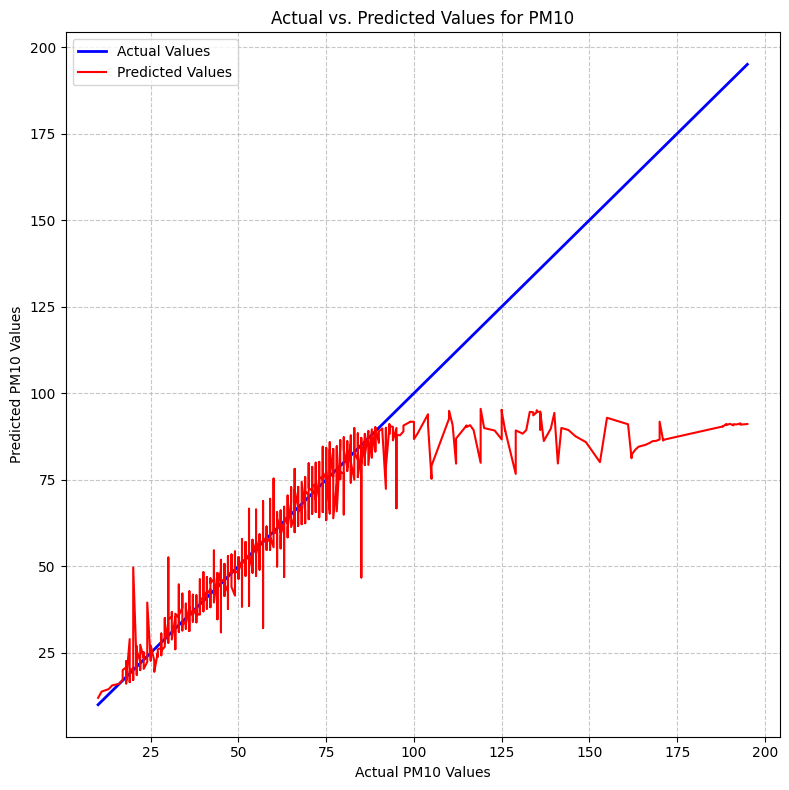

Saved plot for PM10 to prediction_plots/actual_vs_predicted_PM10.png


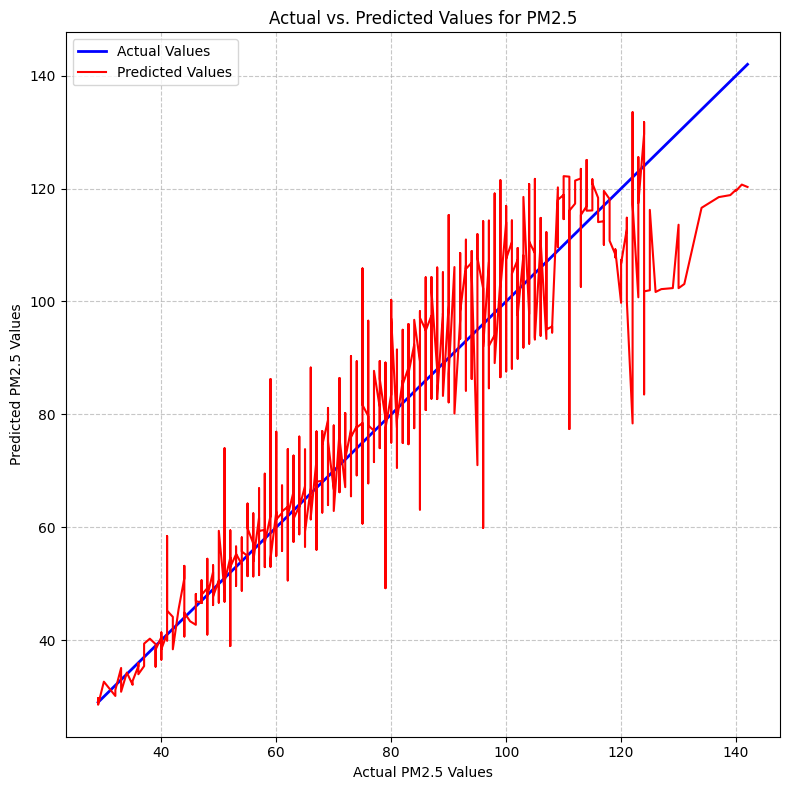

Saved plot for PM2.5 to prediction_plots/actual_vs_predicted_PM2.5.png


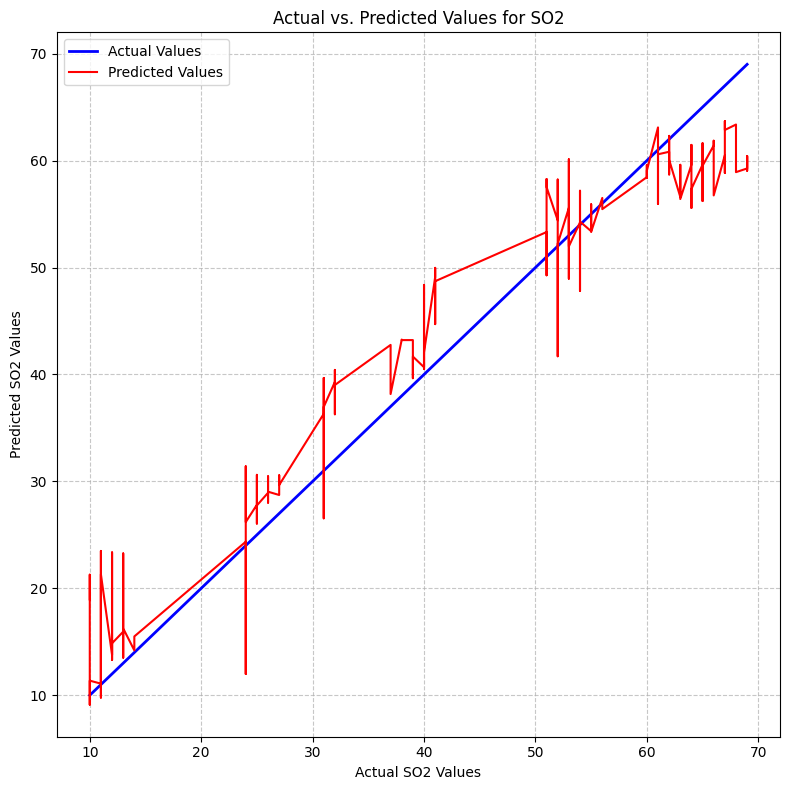

Saved plot for SO2 to prediction_plots/actual_vs_predicted_SO2.png


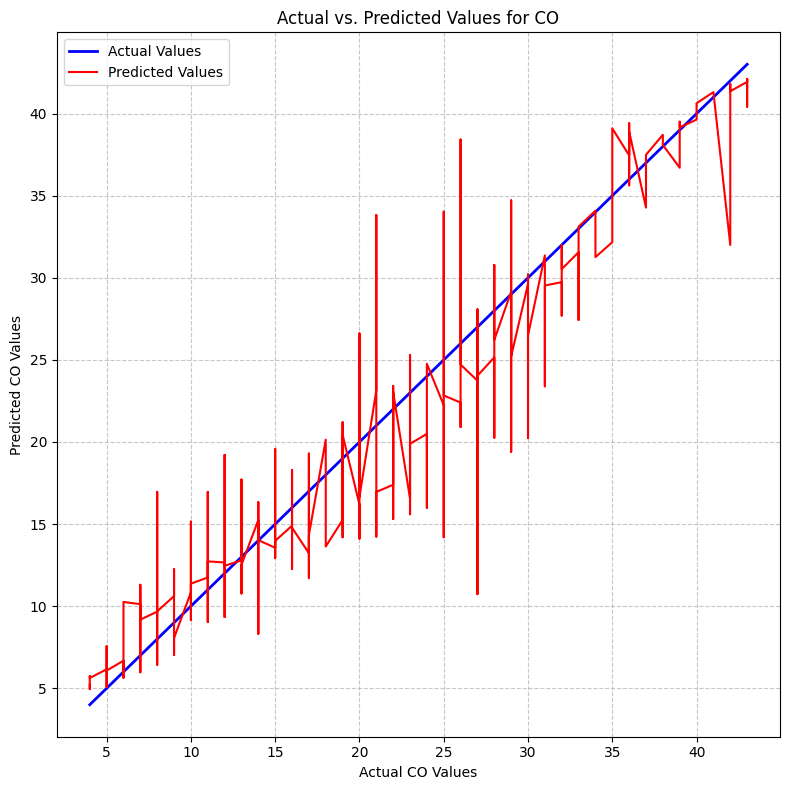

Saved plot for CO to prediction_plots/actual_vs_predicted_CO.png


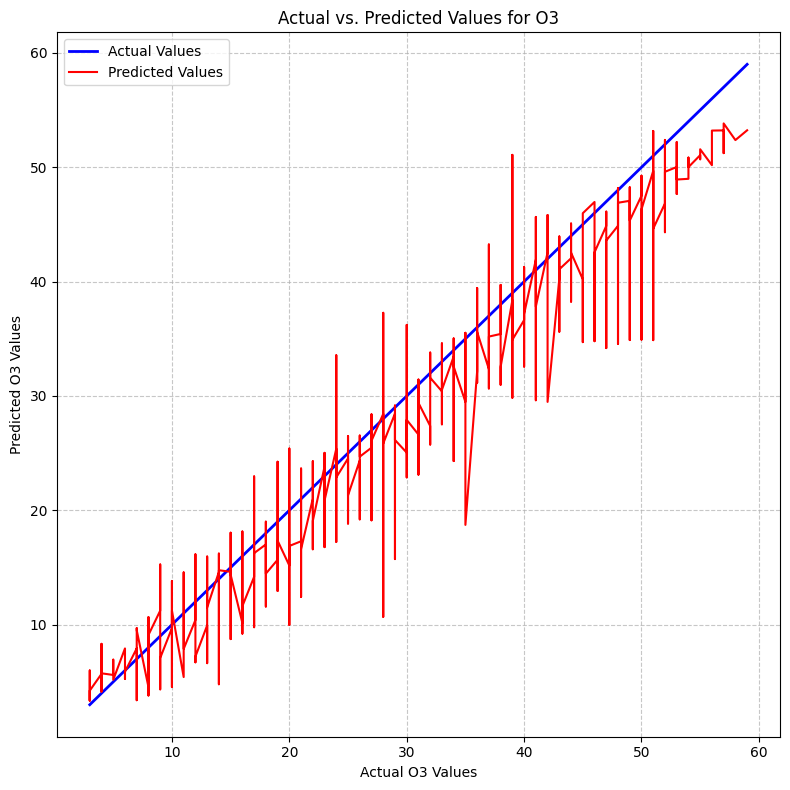

Saved plot for O3 to prediction_plots/actual_vs_predicted_O3.png


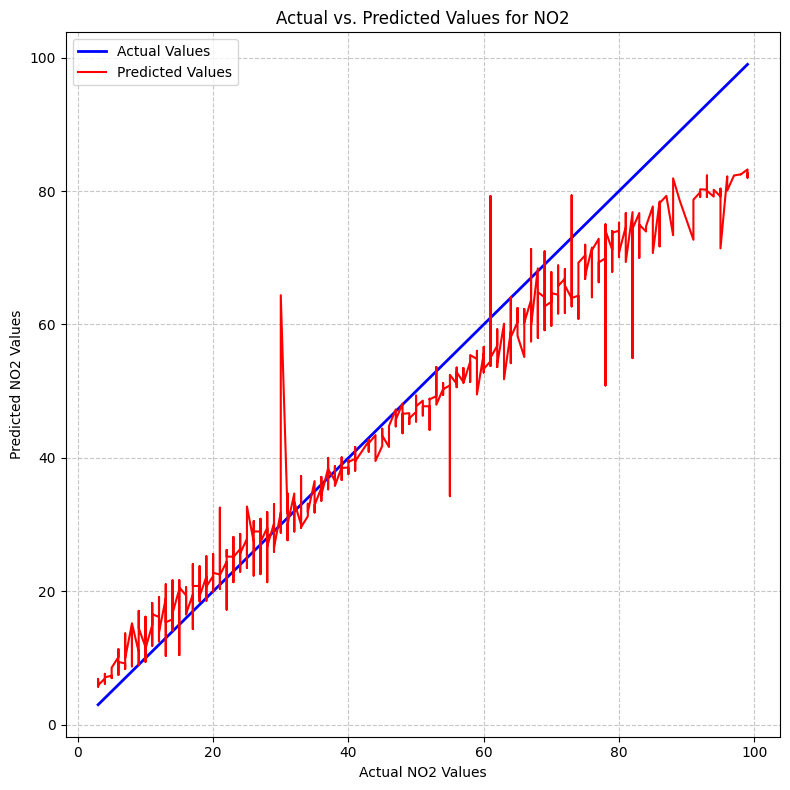

Saved plot for NO2 to prediction_plots/actual_vs_predicted_NO2.png


In [57]:
import matplotlib.pyplot as plt
import os
import numpy as np

# Create a directory for prediction plots if it doesn't exist
prediction_plots_dir = 'prediction_plots'
os.makedirs(prediction_plots_dir, exist_ok=True)
print(f"Prediction plots will be saved in: {prediction_plots_dir}")

# Loop through each pollutant
for i, pollutant_name in enumerate(Y.columns):
    actual_values = y_test[:, i] # Actual values for the current pollutant
    predicted_values = test_predictions[:, i] # Predicted values for the current pollutant

    # Sort by actual_values to create a meaningful line plot
    sort_indices = np.argsort(actual_values)
    sorted_actual_values = actual_values[sort_indices]
    sorted_predicted_values = predicted_values[sort_indices]

    # Create a figure and axes for the line plot
    fig, ax = plt.subplots(figsize=(8, 8))
    # Plot actual values as a blue line
    ax.plot(sorted_actual_values, sorted_actual_values, color='blue', linestyle='-', linewidth=2, label='Actual Values')

    # Plot predicted values as a red line against sorted actual values
    ax.plot(sorted_actual_values, sorted_predicted_values, color='red', linestyle='-', label='Predicted Values')

    # Set plot title and labels
    ax.set_title(f'Actual vs. Predicted Values for {pollutant_name}')
    ax.set_xlabel(f'Actual {pollutant_name} Values')
    ax.set_ylabel(f'Predicted {pollutant_name} Values')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Save the plot as a PNG image
    plot_filename = os.path.join(prediction_plots_dir, f'actual_vs_predicted_{pollutant_name}.png')
    fig.savefig(plot_filename, bbox_inches='tight')
    print(f"Saved plot for {pollutant_name} to {plot_filename}")
    plt.close(fig) # Close the figure to free memory

# Peter-Clark Momentary Conditional Independence (PCMCI)

## Import PCMCI Library

In [58]:
!pip install tigramite -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 2.2 MB/s eta 0:00:00


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

In [60]:
def plot_pcmci_network(
    station_name,
    pollutant,
    alpha_level=0.05
):
    pcmci = pcmci_objects[
        station_name
    ][pollutant]

    results = pcmci_raw_results[
        station_name
    ][pollutant]

    # Get the full graph and value matrix from PCMCI results (tau_min to tau_max)
    full_graph = pcmci.get_graph_from_pmatrix(
        p_matrix=results["p_matrix"],
        alpha_level=alpha_level,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX
    )

    full_val_matrix = results["val_matrix"]

    # Create filtered versions of graph and val_matrix for plotting only desired lags
    graph_filtered = np.copy(full_graph)
    val_matrix_filtered = np.copy(full_val_matrix)

    # Calculate indices corresponding to the desired lags (TAU_MIN is typically 1, so lag X corresponds to index X-1)
    lags_to_keep_indices = [t - TAU_MIN for t in LAG_HOURS_TO_REPORT if TAU_MIN <= t <= TAU_MAX]

    # Iterate through the graph and set connections to empty string/0.0 for undesired lags
    for s_idx in range(full_graph.shape[0]):
        for t_idx in range(full_graph.shape[1]):
            for lag_idx in range(full_graph.shape[2]):
                if lag_idx not in lags_to_keep_indices:
                    graph_filtered[s_idx, t_idx, lag_idx] = '' # Remove string representation of link
                    val_matrix_filtered[s_idx, t_idx, lag_idx] = 0.0 # Set strength to 0

    tp.plot_graph(
        graph=graph_filtered, # Use the filtered graph
        val_matrix=val_matrix_filtered, # Use the filtered value matrix
        var_names=pcmci.var_names,
        link_colorbar_label=
            "PCMCI strength",
        node_colorbar_label=
            "Variable"
    )

    plt.title(
        f"PCMCI Network — "
        f"{pollutant} — {station_name}\n"
        f"Lags Displayed: {LAG_HOURS_TO_REPORT} hours"
    )

    plt.show()

## Create PCMCI Function

In [77]:
import pandas as pd
import numpy as np
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

# ============================================================
# 8. FUNCTION: RUN PCMCI FOR ONE POLLUTANT
# ============================================================

def run_pcmci_for_pollutant(
    station_df,
    target_pollutant,
    traffic_cols,
    meteo_cols,
    tau_min=1,
    tau_max=24,
    alpha_level=0.05
):
    """
    Run PCMCI for one target pollutant at one monitoring station.

    Candidate variables:
        target pollutant
        traffic
        meteorology

    Returns:
        pcmci object
        results
        results dataframe
    """

    station_df = station_df.copy()

    # Candidate variables
    candidate_cols = (
        traffic_cols
        + meteo_cols
        + [target_pollutant]
    )

    # Only retain columns that actually exist
    candidate_cols = [
        col for col in candidate_cols
        if col in station_df.columns
    ]

    # Convert all columns to numeric
    pcmci_df = station_df[
        ["datetime"] + candidate_cols
    ].copy()

    for col in candidate_cols:
        pcmci_df[col] = pd.to_numeric(
            pcmci_df[col],
            errors="coerce"
        )

    # Sort and remove incomplete observations
    pcmci_df = (
        pcmci_df
        .sort_values("datetime")
        .dropna(subset=candidate_cols)
        .reset_index(drop=True)
    )

    if len(pcmci_df) <= tau_max + 20:
        print(
            f"Not enough data for {target_pollutant}: "
            f"{len(pcmci_df)} observations"
        )
        return None, None, None

    data_array = pcmci_df[
        candidate_cols
    ].to_numpy(dtype=float)

    # Standardization recommended for ParCorr
    data_array = (
        data_array - np.mean(data_array, axis=0)
    ) / (
        np.std(data_array, axis=0) + 1e-8
    )

    dataframe = pp.DataFrame(
        data_array,
        var_names=candidate_cols
    )

    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=ParCorr(significance="analytic"),
        verbosity=0
    )

    # Run PCMCI over the full range of taus to get comprehensive results
    results = pcmci.run_pcmci(
        tau_min=tau_min,
        tau_max=tau_max,
        pc_alpha=alpha_level,
        alpha_level=alpha_level
    )

    target_idx = candidate_cols.index(
        target_pollutant
    )

    rows = []

    # Filter results for reporting to only include LAG_HOURS_TO_REPORT
    for source_idx, source_name in enumerate(candidate_cols):

        for tau in range(tau_min, tau_max + 1):
            # Only append if the lag is in the desired reporting list
            if tau not in LAG_HOURS_TO_REPORT:
                continue

            p_value = results["p_matrix"][
                source_idx,
                target_idx,
                tau
            ]

            val = results["val_matrix"][
                source_idx,
                target_idx,
                tau
            ]

            rows.append({
                "Target": target_pollutant,
                "Source": source_name,
                "Lag_h": tau,
                "PCMCI_strength": val,
                "p_value": p_value,
                "Significant":
                    p_value < alpha_level
            })

    result_df = pd.DataFrame(rows)

    result_df = result_df.sort_values(
        ["Significant", "p_value"],
        ascending=[False, True]
    )

    return pcmci, results, result_df

## Run PCMCI For All Stations All Pollutants

In [78]:
pollutant_cols = ["PM10", "PM2.5", "SO2", "CO", "O3", "NO2"]
traffic_cols = ["Speed", "Congestion Level"]
meteo_cols = ["Temperature", "Dew Point", "Humidity", "Wind Speed", "Pressure"]

# Define PCMCI parameters
TAU_MIN = 1
TAU_MAX = 24 # Still calculate over the full range, then filter for reporting/plotting
ALPHA_LEVEL = 0.05

# Specific lag hours to report and plot
LAG_HOURS_TO_REPORT = [1]

In [79]:
# ============================================================
# 9. RUN PCMCI FOR ALL STATIONS AND POLLUTANTS
# ============================================================

all_pcmci_results = []

pcmci_objects = {}
pcmci_raw_results = {}

for station_name, station_df in AQI_Jakarta_df.groupby("Station_Name"):

    print("\n" + "=" * 70)
    print("Station:", station_name)
    print("=" * 70)

    pcmci_objects[station_name] = {}
    pcmci_raw_results[station_name] = {}

    for pollutant in pollutant_cols:

        print(f"Running PCMCI for {pollutant}...")

        pcmci, results, result_df = run_pcmci_for_pollutant(
            station_df=station_df,
            target_pollutant=pollutant,
            traffic_cols=traffic_cols,
            meteo_cols=meteo_cols,
            tau_min=TAU_MIN,
            tau_max=TAU_MAX
        )

        if result_df is None:
            continue

        result_df["Station_Name"] = station_name

        all_pcmci_results.append(
            result_df
        )

        pcmci_objects[station_name][
            pollutant
        ] = pcmci

        pcmci_raw_results[station_name][
            pollutant
        ] = results


pcmci_results_df = pd.concat(
    all_pcmci_results,
    ignore_index=True
)

print("Finished.")
print(pcmci_results_df.shape)


Station: Bundaran_HI
Running PCMCI for PM10...
Running PCMCI for PM2.5...
Running PCMCI for SO2...
Running PCMCI for CO...
Running PCMCI for O3...
Running PCMCI for NO2...

Station: Jagakarsa
Running PCMCI for PM10...
Running PCMCI for PM2.5...
Running PCMCI for SO2...
Running PCMCI for CO...
Running PCMCI for O3...
Running PCMCI for NO2...

Station: Kebun_Jeruk
Running PCMCI for PM10...
Running PCMCI for PM2.5...
Running PCMCI for SO2...
Running PCMCI for CO...
Running PCMCI for O3...
Running PCMCI for NO2...

Station: Kelapa_Gading
Running PCMCI for PM10...
Running PCMCI for PM2.5...
Running PCMCI for SO2...
Running PCMCI for CO...
Running PCMCI for O3...
Running PCMCI for NO2...

Station: Lubang_Buaya
Running PCMCI for PM10...
Running PCMCI for PM2.5...
Running PCMCI for SO2...
Running PCMCI for CO...
Running PCMCI for O3...
Running PCMCI for NO2...
Finished.
(240, 7)


### PCMCI Full Causal Network (All Variables)

This section runs and visualizes PCMCI for each station, considering all pollutants, traffic, and meteorological variables as part of a single, interconnected causal network. This allows for a holistic view of the causal relationships within the local environment.

### Global Jakarta PCMCI Summary

In [80]:
# ============================================================
# 10. SIGNIFICANT PCMCI LINKS (Moved from ZlvrZIvcPYrf to define significant_pcmci before global_summary)
# ============================================================

significant_pcmci = pcmci_results_df[
    pcmci_results_df["Significant"]
].copy()

# Exclude autoregressive target -> target relationship
significant_pcmci = significant_pcmci[
    significant_pcmci["Source"]
    != significant_pcmci["Target"]
]

significant_pcmci = significant_pcmci.sort_values(
    ["Target", "p_value"]
)

display(
    significant_pcmci[
        [
            "Station_Name",
            "Target",
            "Source",
            "Lag_h",
            "PCMCI_strength",
            "p_value"
        ]
    ].head(100)
)

,Station_Name,Target,Source,Lag_h,PCMCI_strength,p_value
217,Lubang_Buaya,CO,Wind Speed,1,-0.055323,0.018908
25,Bundaran_HI,CO,Wind Speed,1,-0.047674,0.030446
169,Kelapa_Gading,CO,Wind Speed,1,-0.048322,0.030659
218,Lubang_Buaya,CO,Dew Point,1,0.048602,0.039226
121,Kebun_Jeruk,CO,Wind Speed,1,-0.050530,0.039305
122,Kebun_Jeruk,CO,Dew Point,1,-0.049799,0.042241
219,Lubang_Buaya,CO,Humidity,1,0.047249,0.045033
41,Bundaran_HI,NO2,Wind Speed,1,-0.063289,0.004049
42,Bundaran_HI,NO2,Speed,1,-0.058751,0.007678
43,Bundaran_HI,NO2,Congestion Level,1,0.058153,0.008289


In [81]:
# ============================================================
# 15. GLOBAL JAKARTA PCMCI SUMMARY
# ============================================================

global_summary = (
    significant_pcmci
    [
        significant_pcmci["Source"]
        != significant_pcmci["Target"]
    ]
    .groupby(
        ["Target", "Source", "Lag_h"]
    )
    .agg(
        Stations_Significant=(
            "Station_Name",
            "nunique"
        ),
        Mean_Strength=(
            "PCMCI_strength",
            "mean"
        ),
        Median_Strength=(
            "PCMCI_strength",
            "median"
        ),
        Mean_p_value=(
            "p_value",
            "mean"
        )
    )
    .reset_index()
)

global_summary = global_summary.sort_values(
    [
        "Target",
        "Stations_Significant",
        "Mean_p_value"
    ],
    ascending=[
        True,
        False,
        True
    ]
)

In [82]:
def run_pcmci_full_network(
    station_df,
    all_variables,
    tau_min=1,
    tau_max=24,
    alpha_level=0.05
):
    """
    Run PCMCI for a full network of variables at one monitoring station.

    Candidate variables: all specified pollutants, traffic, and meteorology.

    Returns:
        pcmci object
        results
    """

    station_df = station_df.copy()

    # Only retain columns that actually exist
    candidate_cols = [
        col for col in all_variables
        if col in station_df.columns
    ]

    # Convert all columns to numeric
    pcmci_df = station_df[
        ["datetime"] + candidate_cols
    ].copy()

    for col in candidate_cols:
        pcmci_df[col] = pd.to_numeric(
            pcmci_df[col],
            errors="coerce"
        )

    # Sort and remove incomplete observations
    pcmci_df = (
        pcmci_df
        .sort_values("datetime")
        .dropna(subset=candidate_cols)
        .reset_index(drop=True)
    )

    if len(pcmci_df) <= tau_max + 20:
        print(
            f"Not enough data for full network PCMCI at this station: "
            f"{len(pcmci_df)} observations"
        )
        return None, None

    data_array = pcmci_df[
        candidate_cols
    ].to_numpy(dtype=float)

    # Standardization recommended for ParCorr
    data_array = (
        data_array - np.mean(data_array, axis=0)
    ) / (
        np.std(data_array, axis=0) + 1e-8
    )

    dataframe = pp.DataFrame(
        data_array,
        var_names=candidate_cols
    )

    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=ParCorr(significance="analytic"),
        verbosity=0
    )

    results = pcmci.run_pcmci(
        tau_min=tau_min,
        tau_max=tau_max,
        pc_alpha=alpha_level,
        alpha_level=alpha_level
    )
    return pcmci, results

In [83]:
import os

def plot_pcmci_full_network(
    pcmci_object,
    results_object,
    station_name,
    alpha_level=0.05,
    lags_to_display=LAG_HOURS_TO_REPORT,
    pollutant_vars=[],
    traffic_vars=[],
    meteo_vars=[]
):
    """
    Plot a single PCMCI network graph for all variables at a given station.
    """

    # Get the full graph and value matrix from PCMCI results (tau_min to tau_max)
    full_graph = pcmci_object.get_graph_from_pmatrix(
        p_matrix=results_object["p_matrix"],
        alpha_level=alpha_level,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX
    )

    full_val_matrix = results_object["val_matrix"]

    # Filter out lags not in lags_to_display
    graph_filtered = np.copy(full_graph)
    val_matrix_filtered = np.copy(full_val_matrix)

    # Calculate indices corresponding to the desired lags (TAU_MIN is typically 1)
    lags_to_keep_indices = [t - TAU_MIN for t in lags_to_display if TAU_MIN <= t <= TAU_MAX]

    # Iterate through the graph and set connections to empty string/0.0 for undesired lags
    for s_idx in range(full_graph.shape[0]):
        for t_idx in range(full_graph.shape[1]):
            for lag_idx in range(full_graph.shape[2]):
                if lag_idx not in lags_to_keep_indices:
                    graph_filtered[s_idx, t_idx, lag_idx] = '' # Remove string representation of link
                    val_matrix_filtered[s_idx, t_idx, lag_idx] = 0.0 # Set strength to 0

    # Determine node groups and custom colormap based on variable categories
    node_group_labels = []
    unique_groups = set()
    for var in pcmci_object.var_names:
        if var in pollutant_vars:
            node_group_labels.append('Pollutant')
            unique_groups.add('Pollutant')
        elif var in traffic_vars:
            node_group_labels.append('Traffic')
            unique_groups.add('Traffic')
        elif var in meteo_vars:
            node_group_labels.append('Meteorology')
            unique_groups.add('Meteorology')
        else:
            node_group_labels.append('Other')
            unique_groups.add('Other')

    # Define the custom colormap for node groups
    node_group_cmap = {
        'Pollutant': 'lightpink',
        'Traffic': 'lightblue',
        'Meteorology': 'lightyellow'
    }

    # Filter node_group_cmap to only include groups actually present in this plot
    filtered_node_group_cmap = {group: color for group, color in node_group_cmap.items() if group in unique_groups}

    fig, ax = tp.plot_graph(
        graph=graph_filtered,
        val_matrix=val_matrix_filtered,
        var_names=pcmci_object.var_names,
        link_colorbar_label="PCMCI strength",
        node_colorbar_label="Variable",
        node_group=node_group_labels, # Use node_group instead of node_color
        node_group_cmap=filtered_node_group_cmap # Pass the custom colormap
    )

    plt.title(
        f"PCMCI Full Causal Network — {station_name}\n"
        f"Lags Displayed: {lags_to_display} hours"
    )
    # Create a directory for plots if it doesn't exist
    output_dir = 'pcmci_plots'
    os.makedirs(output_dir, exist_ok=True)
    plot_filename = os.path.join(output_dir, f'pcmci_full_network_{station_name}.png')
    fig.savefig(plot_filename, bbox_inches='tight')
    print(f"Saved PCMCI network plot for {station_name} to {plot_filename}")
    plt.close(fig) # Close the figure to free memory after saving


In [84]:
# ============================================================
# RUN FULL NETWORK PCMCI FOR ALL STATIONS
# ============================================================

all_network_variables = pollutant_cols + traffic_cols + meteo_cols

pcmci_full_network_objects = {}
pcmci_full_network_raw_results = {}

for station_name, station_df in AQI_Jakarta_df.groupby("Station_Name"):

    print("\n" + "=" * 70)
    print("Running Full Network PCMCI for Station:", station_name)
    print("=" * 70)

    pcmci_obj, results_obj = run_pcmci_full_network(
        station_df=station_df,
        all_variables=all_network_variables,
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        alpha_level=ALPHA_LEVEL
    )

    if pcmci_obj is not None:
        pcmci_full_network_objects[station_name] = pcmci_obj
        pcmci_full_network_raw_results[station_name] = results_obj
        # The individual plot_pcmci_full_network call has been removed.
        # An aggregated plot will be generated in a subsequent cell.
    else:
        print(f"Skipping PCMCI for {station_name} due to insufficient data.")

print("Finished running full network PCMCI. Individual station plots will not be generated in this cell.")
print("An aggregated causal network across all stations will be plotted in a subsequent cell.")


Running Full Network PCMCI for Station: Bundaran_HI

Running Full Network PCMCI for Station: Jagakarsa

Running Full Network PCMCI for Station: Kebun_Jeruk

Running Full Network PCMCI for Station: Kelapa_Gading

Running Full Network PCMCI for Station: Lubang_Buaya
Finished running full network PCMCI. Individual station plots will not be generated in this cell.
An aggregated causal network across all stations will be plotted in a subsequent cell.



--- Plotting Aggregated Causal Network Summary ---


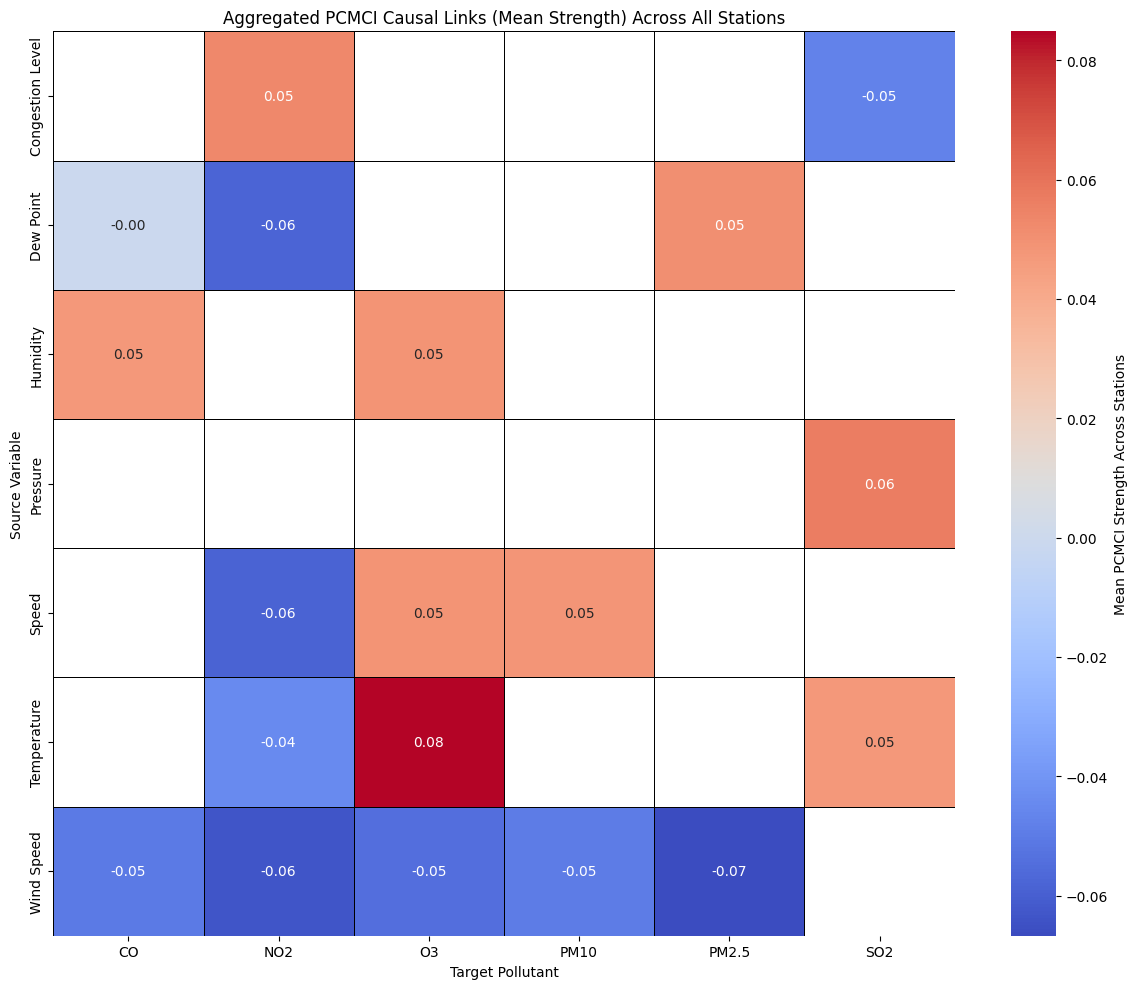

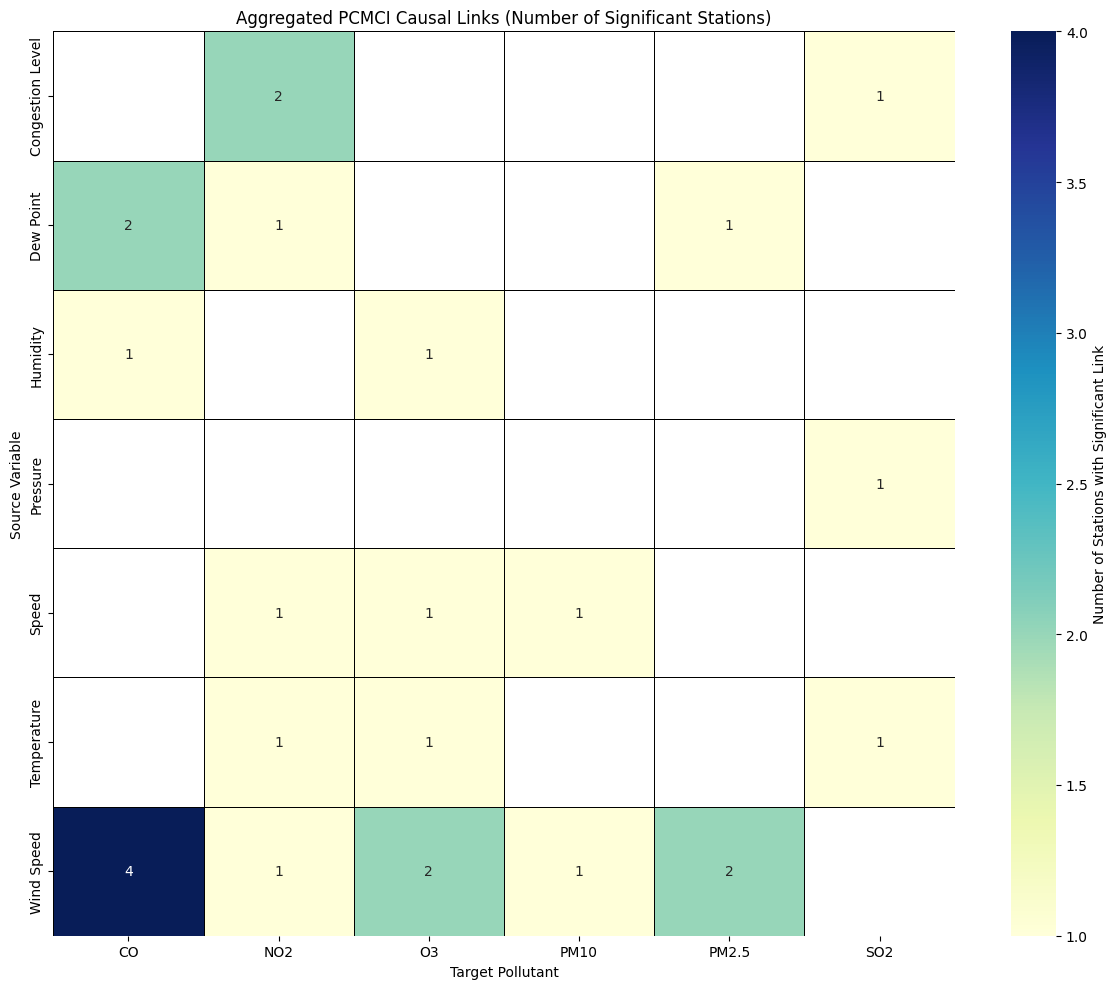

In [85]:
# ============================================================
# PLOT AGGREGATE PCMCI CAUSAL NETWORKS FROM GLOBAL SUMMARY
# ============================================================

print("\n--- Plotting Aggregated Causal Network Summary ---")

# Filter out self-causation (Target == Source)
filtered_global_summary = global_summary[
    global_summary["Target"] != global_summary["Source"]
].copy()

if filtered_global_summary.empty:
    print("No significant aggregated links found to plot.")
else:
    # Pivot the table to create a matrix suitable for a heatmap
    # Rows: Source, Columns: Target, Values: Mean_Strength or Stations_Significant
    # Let's use Mean_Strength for the heatmap values
    heatmap_data = filtered_global_summary.pivot_table(
        index='Source',
        columns='Target',
        values='Mean_Strength',
        aggfunc='mean' # Aggregate if multiple lags exist for a Source-Target pair
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        heatmap_data,
        annot=True,     # Show the numerical values
        cmap='coolwarm', # Color map
        fmt=".2f",      # Format annotations to 2 decimal places
        linewidths=.5,  # Add lines between cells
        linecolor='black', # Line color
        cbar_kws={'label': 'Mean PCMCI Strength Across Stations'}
    )
    plt.title('Aggregated PCMCI Causal Links (Mean Strength) Across All Stations')
    plt.xlabel('Target Pollutant')
    plt.ylabel('Source Variable')
    plt.tight_layout()
    plt.show()

    # Alternatively, you could also plot based on 'Stations_Significant'
    heatmap_data_stations = filtered_global_summary.pivot_table(
        index='Source',
        columns='Target',
        values='Stations_Significant',
        aggfunc='max' # Max number of stations where significant
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        heatmap_data_stations,
        annot=True,
        cmap='YlGnBu',
        fmt=".0f", # Changed from "d" to ".0f" to handle potential float values while displaying as integers
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Number of Stations with Significant Link'}
    )
    plt.title('Aggregated PCMCI Causal Links (Number of Significant Stations)')
    plt.xlabel('Target Pollutant')
    plt.ylabel('Source Variable')
    plt.tight_layout()
    plt.show()

## Show PCMCI Significance

In [86]:
# ============================================================
# 10. SIGNIFICANT PCMCI LINKS
# ============================================================

significant_pcmci = pcmci_results_df[
    pcmci_results_df["Significant"]
].copy()

# Exclude autoregressive target -> target relationship
significant_pcmci = significant_pcmci[
    significant_pcmci["Source"]
    != significant_pcmci["Target"]
]

significant_pcmci = significant_pcmci.sort_values(
    ["Target", "p_value"]
)

display(
    significant_pcmci[
        [
            "Station_Name",
            "Target",
            "Source",
            "Lag_h",
            "PCMCI_strength",
            "p_value"
        ]
    ].head(100)
)

,Station_Name,Target,Source,Lag_h,PCMCI_strength,p_value
217,Lubang_Buaya,CO,Wind Speed,1,-0.055323,0.018908
25,Bundaran_HI,CO,Wind Speed,1,-0.047674,0.030446
169,Kelapa_Gading,CO,Wind Speed,1,-0.048322,0.030659
218,Lubang_Buaya,CO,Dew Point,1,0.048602,0.039226
121,Kebun_Jeruk,CO,Wind Speed,1,-0.050530,0.039305
122,Kebun_Jeruk,CO,Dew Point,1,-0.049799,0.042241
219,Lubang_Buaya,CO,Humidity,1,0.047249,0.045033
41,Bundaran_HI,NO2,Wind Speed,1,-0.063289,0.004049
42,Bundaran_HI,NO2,Speed,1,-0.058751,0.007678
43,Bundaran_HI,NO2,Congestion Level,1,0.058153,0.008289


## Top PCMCI Driver for Each Pollutant

In [87]:
# ============================================================
# 11. TOP PCMCI LINKS PER POLLUTANT
# ============================================================

top_links = (
    significant_pcmci
    .sort_values(
        "PCMCI_strength",
        key=lambda x: np.abs(x),
        ascending=False
    )
    .groupby(
        ["Station_Name", "Target"],
        group_keys=False
    )
    .head(10)
)

display(
    top_links[
        [
            "Station_Name",
            "Target",
            "Source",
            "Lag_h",
            "PCMCI_strength",
            "p_value"
        ]
    ]
)

,Station_Name,Target,Source,Lag_h,PCMCI_strength,p_value
225,Lubang_Buaya,O3,Temperature,1,0.084843,0.000315
105,Kebun_Jeruk,PM2.5,Wind Speed,1,-0.073973,0.002533
41,Bundaran_HI,NO2,Wind Speed,1,-0.063289,0.004049
153,Kelapa_Gading,PM2.5,Wind Speed,1,-0.059441,0.007776
177,Kelapa_Gading,O3,Wind Speed,1,-0.059298,0.007942
42,Bundaran_HI,NO2,Speed,1,-0.058751,0.007678
43,Bundaran_HI,NO2,Congestion Level,1,0.058153,0.008289
44,Bundaran_HI,NO2,Dew Point,1,-0.057965,0.008501
209,Lubang_Buaya,SO2,Pressure,1,0.056696,0.016083
217,Lubang_Buaya,CO,Wind Speed,1,-0.055323,0.018908


## Plot Lag Effect Strength For Each Pollutant

In [88]:
# ============================================================
# 12. PCMCI LAG EFFECT PLOT
# ============================================================

def plot_pcmci_lag_effects(
    result_df,
    station_name,
    pollutant,
    top_n=8
):
    temp = result_df[
        (result_df["Station_Name"] == station_name)
        & (result_df["Target"] == pollutant)
        & (result_df["Significant"])
        & (result_df["Source"] != pollutant)
    ].copy()

    if temp.empty:
        print(
            f"No significant links for "
            f"{pollutant} at {station_name}"
        )
        return

    source_rank = (
        temp.assign(
            abs_strength=
            np.abs(temp["PCMCI_strength"])
        )
        .groupby("Source")[
            "abs_strength"
        ]
        .max()
        .sort_values(
            ascending=False
        )
        .head(top_n)
        .index
    )

    temp = temp[
        temp["Source"].isin(source_rank)
    ]

    plt.figure(figsize=(12, 6))

    for source in source_rank:

        sub = (
            temp[
                temp["Source"] == source
            ]
            .sort_values("Lag_h")
        )

        plt.plot(
            sub["Lag_h"],
            sub["PCMCI_strength"],
            marker="o",
            label=source
        )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel("Lag (hours)")
    plt.ylabel("PCMCI conditional association strength")

    plt.title(
        f"PCMCI Lag Effects for {pollutant} — "
        f"{station_name}"
    )

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

## Heatmap For Each Pollutant

In [89]:
# ============================================================
# 13. PCMCI HEATMAP
# ============================================================

def plot_pcmci_heatmap(
    result_df,
    station_name,
    pollutant,
    alpha_level=0.05
):
    temp = result_df[
        (result_df["Station_Name"] == station_name)
        & (result_df["Target"] == pollutant)
        & (result_df["Source"] != pollutant)
        & (result_df["p_value"] < alpha_level)
    ].copy()

    if temp.empty:
        print(
            f"No significant links for "
            f"{pollutant} at {station_name}"
        )
        return

    pivot = temp.pivot_table(
        index="Source",
        columns="Lag_h",
        values="PCMCI_strength",
        aggfunc="mean"
    )

    plt.figure(
        figsize=(14, max(5, 0.4 * len(pivot)))
    )

    plt.imshow(
        pivot.values,
        aspect="auto"
    )

    plt.colorbar(
        label="PCMCI strength"
    )

    plt.yticks(
        range(len(pivot.index)),
        pivot.index
    )

    plt.xticks(
        range(len(pivot.columns)),
        pivot.columns
    )

    plt.xlabel("Lag (hours)")
    plt.ylabel("Source variable")

    plt.title(
        f"PCMCI Significant Lagged Drivers of {pollutant}\n"
        f"{station_name}"
    )

    plt.tight_layout()
    plt.show()

## Summary All Stations

In [90]:
# ============================================================
# 15. GLOBAL JAKARTA PCMCI SUMMARY
# ============================================================

global_summary = (
    significant_pcmci
    [
        significant_pcmci["Source"]
        != significant_pcmci["Target"]
    ]
    .groupby(
        ["Target", "Source", "Lag_h"]
    )
    .agg(
        Stations_Significant=(
            "Station_Name",
            "nunique"
        ),
        Mean_Strength=(
            "PCMCI_strength",
            "mean"
        ),
        Median_Strength=(
            "PCMCI_strength",
            "median"
        ),
        Mean_p_value=(
            "p_value",
            "mean"
        )
    )
    .reset_index()
)

global_summary = global_summary.sort_values(
    [
        "Target",
        "Stations_Significant",
        "Mean_p_value"
    ],
    ascending=[
        True,
        False,
        True
    ]
)

display(global_summary.head(100))

,Target,Source,Lag_h,Stations_Significant,Mean_Strength,Median_Strength,Mean_p_value
2,CO,Wind Speed,1,4,-0.050462,-0.049426,0.029830
0,CO,Dew Point,1,2,-0.000598,-0.000598,0.040733
1,CO,Humidity,1,1,0.047249,0.047249,0.045033
3,NO2,Congestion Level,1,2,0.053195,0.053195,0.024481
7,NO2,Wind Speed,1,1,-0.063289,-0.063289,0.004049
5,NO2,Speed,1,1,-0.058751,-0.058751,0.007678
4,NO2,Dew Point,1,1,-0.057965,-0.057965,0.008501
6,NO2,Temperature,1,1,-0.044591,-0.044591,0.046054
11,O3,Wind Speed,1,2,-0.054432,-0.054432,0.025641
10,O3,Temperature,1,1,0.084843,0.084843,0.000315


### Aggregated PCMCI Causal Network Graph

This graph visualizes the aggregated causal relationships across all stations. Nodes represent variables (pollutants, traffic, meteorological features), and directed edges represent significant causal links. The color of the edge indicates the mean PCMCI strength across stations (red for positive, blue for negative correlation), and the thickness of the edge indicates the number of stations where that specific causal link was found to be significant. The numbers on the edges denote the lag in hours.


--- Generating Aggregated PCMCI Causal Network Graph ---


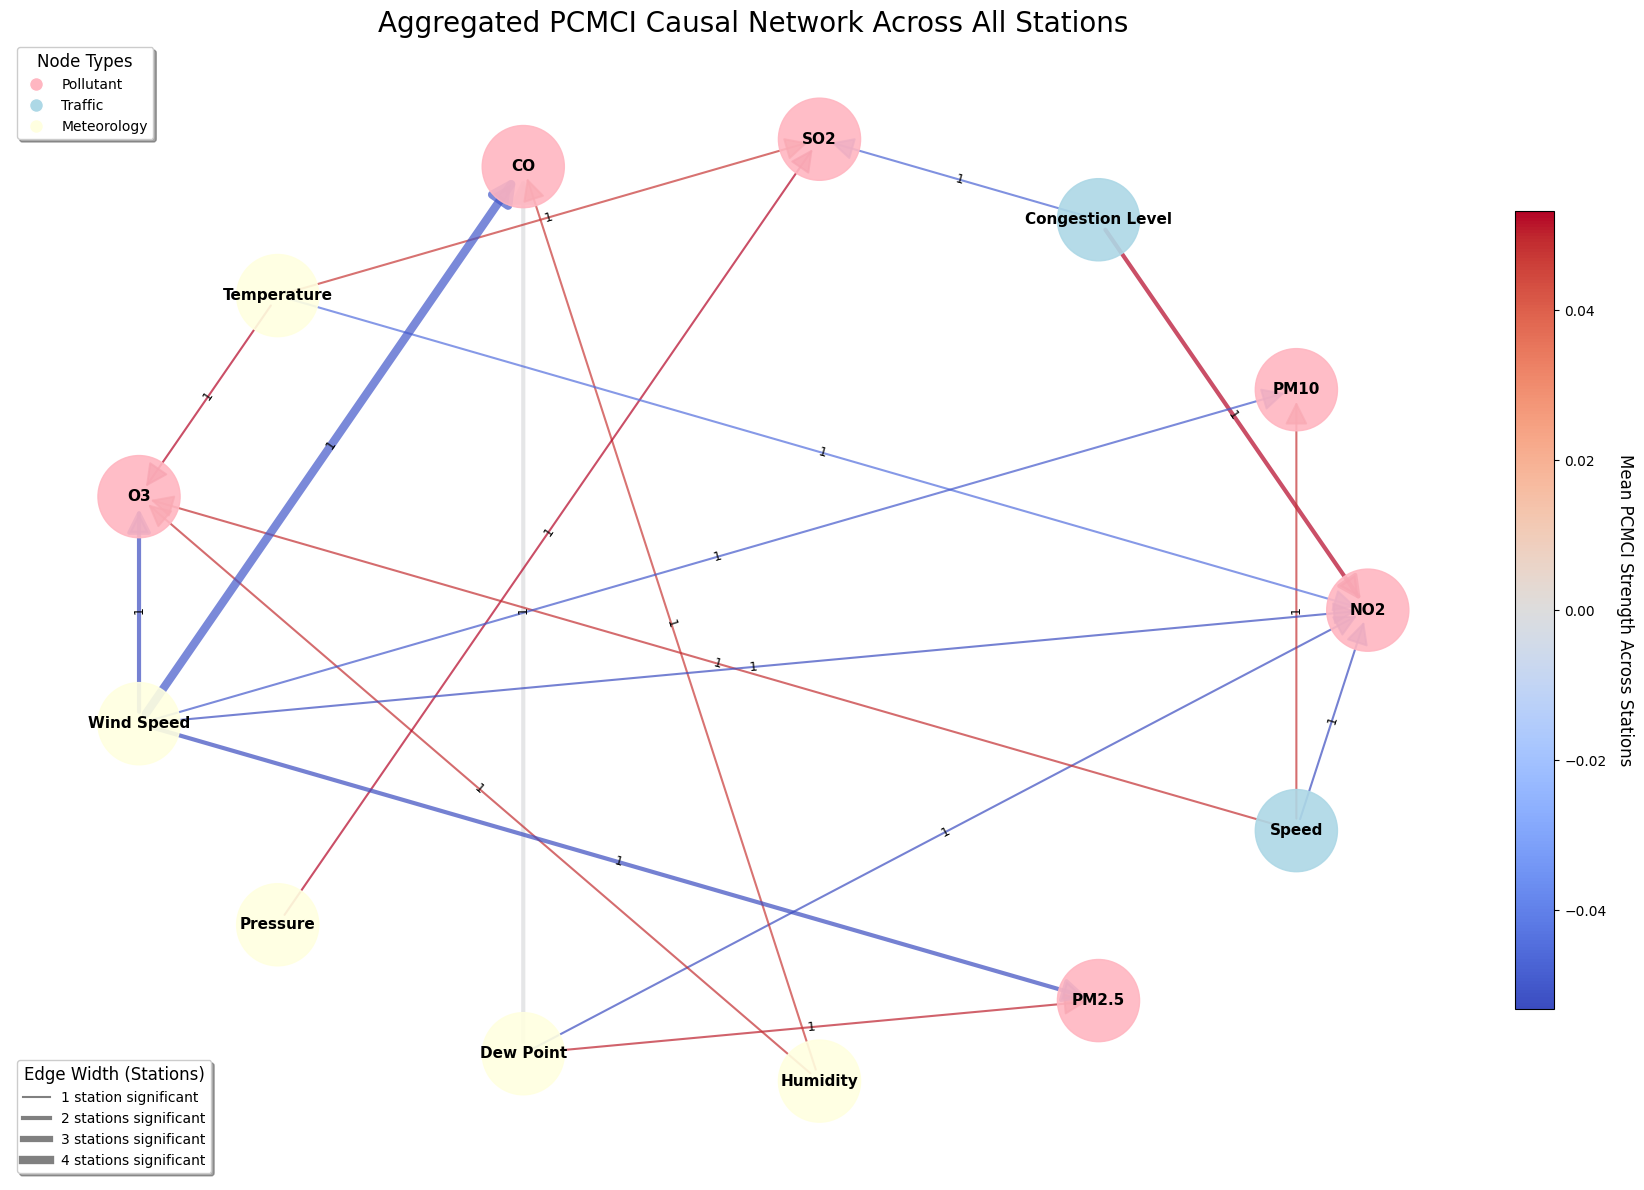

In [91]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.lines import Line2D

print("\n--- Generating Aggregated PCMCI Causal Network Graph ---")

# Filter for links that are significant in at least 1 station
plot_data = global_summary[global_summary['Stations_Significant'] >= 1].copy()

if plot_data.empty:
    print("No significant aggregated causal links found to plot.")
else:
    # Clean 'Source' and 'Target' columns to remove any potential whitespace issues
    plot_data['Source'] = plot_data['Source'].str.strip()
    plot_data['Target'] = plot_data['Target'].str.strip()

    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes
    all_variables = list(set(plot_data['Source'].unique()).union(set(plot_data['Target'].unique())))
    for var in all_variables:
        G.add_node(var)

    # Define colors for different node types
    node_color_map = {
        'Pollutant': 'lightpink',
        'Traffic': 'lightblue',
        'Meteorology': 'lightyellow'
    }

    # Assign colors to each node based on its category
    node_colors = []
    for var in G.nodes():
        if var in pollutant_cols:
            node_colors.append(node_color_map['Pollutant'])
        elif var in traffic_cols:
            node_colors.append(node_color_map['Traffic'])
        elif var in meteo_cols:
            node_colors.append(node_color_map['Meteorology'])
        else:
            node_colors.append(node_color_map['Other'])

    # Define color map for edge strength
    cmap = plt.cm.coolwarm
    norm = mcolors.CenteredNorm() # Centers the colormap around 0 for positive/negative strengths

    # Aggregate lags for edges that appear multiple times between the same source and target
    # This ensures a single edge for each (source, target) pair with aggregated lag info.
    agg_edge_data = plot_data.groupby(['Source', 'Target']).agg(
        mean_strength=('Mean_Strength', 'mean'),
        max_stations_sig=('Stations_Significant', 'max'),
        lags=('Lag_h', lambda x: ','.join(map(str, sorted(x))))
    ).reset_index()

    # Explicitly re-strip Source and Target columns after aggregation for robustness
    agg_edge_data['Source'] = agg_edge_data['Source'].str.strip()
    agg_edge_data['Target'] = agg_edge_data['Target'].str.strip()

    edge_list = []
    edge_colors = []
    edge_widths = []
    edge_labels = {}

    for index, row in agg_edge_data.iterrows():
        source = row['Source']
        target = row['Target']
        mean_strength = row['mean_strength'] # Corrected: 'Mean_Strength' to 'mean_strength'
        stations_significant = row['max_stations_sig']
        lags_str = row['lags']

        G.add_edge(source, target,
                   strength=mean_strength,
                   stations_sig=stations_significant,
                   lag=lags_str)

        edge_list.append((source, target))
        edge_colors.append(cmap(norm(mean_strength)))
        # Scale width: Adjust the multiplier for desired thickness
        edge_widths.append(stations_significant * 1.5) # Increased multiplier for better visibility
        edge_labels[(source, target)] = lags_str

    plt.figure(figsize=(18, 12)) # Larger figure size for better readability
    pos = nx.circular_layout(G) # Using circular layout for clarity

    # Draw nodes with custom colors
    nx.draw_networkx_nodes(G, pos, node_size=3500, node_color=node_colors, alpha=0.9)

    # Draw edges
    arrows = nx.draw_networkx_edges(G, pos,
                                    edgelist=edge_list,
                                    edge_color=edge_colors,
                                    width=edge_widths,
                                    arrowstyle='-|>', # Changed to a more distinct arrow style
                                    arrowsize=35, # Increased arrow size for better visibility
                                    alpha=0.7,
                                    label='Causal Link')

    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

    # Draw edge labels (lags)
    # The 'pos' argument here should be the node positions, not custom label positions.
    # networkx will calculate label positions based on 'pos' and 'label_pos' (default 0.5, midpoint).
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=9, bbox={"alpha":0})

    plt.title('Aggregated PCMCI Causal Network Across All Stations', size=20)
    plt.axis('off')

    # Add a color bar for the edge strength
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([-1, 1]) # Range of strength values, assuming strength is between -1 and 1
    cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.7, pad=0.01)
    cbar.set_label('Mean PCMCI Strength Across Stations', rotation=270, labelpad=20, fontsize=12)

    # Add a legend for edge width (number of significant stations)
    max_stations_val = agg_edge_data['max_stations_sig'].max()
    legend_elements = [
        Line2D([0], [0], color='gray', lw=1*1.5, label='1 station significant'),
        Line2D([0], [0], color='gray', lw=max(1, min(2, max_stations_val))*1.5, label='2 stations significant'),
        Line2D([0], [0], color='gray', lw=max(1, min(3, max_stations_val))*1.5, label='3 stations significant'),
        Line2D([0], [0], color='gray', lw=max(1, min(4, max_stations_val))*1.5, label='4 stations significant'),
        Line2D([0], [0], color='gray', lw=max(1, min(5, max_stations_val))*1.5, label='5 stations significant')
    ]
    # Filter legend to only show relevant station counts
    legend_elements = [le for le in legend_elements if float(le.get_label().split()[0]) <= max_stations_val]

    # Add a legend for node colors
    node_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Pollutant', markerfacecolor='lightpink', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Traffic', markerfacecolor='lightblue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Meteorology', markerfacecolor='lightyellow', markersize=10)
    ]

    # Combine legends
    # Create a single legend with two handles containers
    # One for node colors, one for edge widths
    legend1 = plt.legend(handles=node_legend_elements, loc='upper left', title='Node Types', fontsize=10, title_fontsize=12, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0, 1))
    plt.gca().add_artist(legend1)
    plt.legend(handles=legend_elements, loc='lower left', title='Edge Width (Stations)', fontsize=10, title_fontsize=12, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0, 0))

    plt.tight_layout()
    plt.show()

## Export Results

In [92]:
# ============================================================
# 16. EXPORT
# ============================================================

pcmci_results_df.to_csv(
    "/content/PCMCI_AQI_Jakarta_2024_All_Pollutants.csv",
    index=False
)

global_summary.to_csv(
    "/content/PCMCI_AQI_Jakarta_2024_Global_Summary.csv",
    index=False
)

print("Files saved.")

Files saved.
